<a href="https://colab.research.google.com/github/Nouran-Khallaf/Data-AI-Hackathon-Task1-ChallengeA/blob/main/late_refill_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!ls -l /content/sample_data/

total 55504
-rwxr-xr-x 1 root root     1697 Jan  1  2000 anscombe.json
-rw-r--r-- 1 root root   301141 Mar 23 13:29 california_housing_test.csv
-rw-r--r-- 1 root root  1706430 Mar 23 13:29 california_housing_train.csv
-rw-r--r-- 1 root root 18289443 Mar 23 13:29 mnist_test.csv
-rw-r--r-- 1 root root 36523880 Mar 23 13:29 mnist_train_small.csv
-rwxr-xr-x 1 root root      962 Jan  1  2000 README.md


In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("/content/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")

/tmp/ipykernel_7002/862823126.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")


In [5]:
df.head()

,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT
0,00013D2EFD8E45D1,233664490397622,20080103,247037252,30.0,20.0,10.0,120.0
1,00013D2EFD8E45D1,233644490171972,20080105,223039502,10.0,10.0,0.0,0.0
2,00013D2EFD8E45D1,233974489116848,20080109,364724812,120.0,30.0,10.0,110.0
3,00013D2EFD8E45D1,233574491083209,20080123,179180672,30.0,30.0,0.0,240.0
4,00013D2EFD8E45D1,233024491180571,20080124,58016005300,30.0,30.0,70.0,70.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095939 entries, 0 to 2095938
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   DESYNPUF_ID     object 
 1   PDE_ID          int64  
 2   SRVC_DT         int64  
 3   PROD_SRVC_ID    object 
 4   QTY_DSPNSD_NUM  float64
 5   DAYS_SUPLY_NUM  float64
 6   PTNT_PAY_AMT    float64
 7   TOT_RX_CST_AMT  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 127.9+ MB


In [8]:
df.describe()

,PDE_ID,SRVC_DT,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT
count,2.095939e+06,2.095939e+06,2.095939e+06,2.095938e+06,2.095938e+06,2.095938e+06
mean,2.335043e+14,2.008955e+07,5.117875e+01,3.417874e+01,1.029748e+01,6.146948e+01
std,2.857629e+11,7.673734e+03,5.186897e+01,2.124516e+01,2.408872e+01,9.447219e+01
min,2.330145e+14,2.008010e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.332545e+14,2.008092e+07,3.000000e+01,3.000000e+01,0.000000e+00,1.000000e+01
50%,2.335045e+14,2.009051e+07,3.000000e+01,3.000000e+01,0.000000e+00,2.000000e+01
75%,2.337545e+14,2.009123e+07,6.000000e+01,3.000000e+01,1.000000e+01,8.000000e+01
max,2.339945e+14,2.010123e+07,3.600000e+02,9.000000e+01,1.700000e+02,5.700000e+02


In [9]:
print('Unique DESYNPUF_ID count:', df['DESYNPUF_ID'].nunique())
print('Unique PDE_ID count:', df['PDE_ID'].nunique())
print('Unique PROD_SRVC_ID count:', df['PROD_SRVC_ID'].nunique())

Unique DESYNPUF_ID count: 37844
Unique PDE_ID count: 2095939
Unique PROD_SRVC_ID count: 409383


In [10]:
# Convert SRVC_DT to datetime objects
df['SRVC_DT'] = pd.to_datetime(df['SRVC_DT'].astype(str))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095939 entries, 0 to 2095938
Data columns (total 8 columns):
 #   Column          Dtype         
---  ------          -----         
 0   DESYNPUF_ID     object        
 1   PDE_ID          int64         
 2   SRVC_DT         datetime64[ns]
 3   PROD_SRVC_ID    object        
 4   QTY_DSPNSD_NUM  float64       
 5   DAYS_SUPLY_NUM  float64       
 6   PTNT_PAY_AMT    float64       
 7   TOT_RX_CST_AMT  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 127.9+ MB


Based on the column names and data types, we can group them as follows:

*   **Patient and Event Identifiers**: `DESYNPUF_ID`, `PDE_ID` (These uniquely identify patients and prescription drug events).
*   **Product Identifier**: `PROD_SRVC_ID` (Identifies the specific product or service).
*   **Date of Service**: `SRVC_DT` (Represents when the service was rendered).
*   **Prescription Details and Costs**: `QTY_DSPNSD_NUM`, `DAYS_SUPLY_NUM`, `PTNT_PAY_AMT`, `TOT_RX_CST_AMT` (These describe the quantity, duration of supply, and associated costs).

# Task
Perform a comprehensive exploratory data analysis (EDA) on the provided prescription drug events dataset, `df`, to analyze temporal patterns of prescriptions, identify frequently prescribed products, analyze patient spending behaviors, and conduct a correlation analysis of key numerical features. Based on the insights gained, engineer new features suitable for machine learning models and propose potential modeling tasks.

## Analyze Temporal Patterns of Prescriptions

### Subtask:
Extract year and month from the 'SRVC_DT' column. Group the data by these temporal units (e.g., month, year) to calculate the total quantity dispensed, patient pay amounts, and total prescription costs over time. Visualize these trends using line plots to identify any seasonal or yearly patterns.


**Reasoning**:
First, I'll extract the year and month from the 'SRVC_DT' column and create new columns for them. This is the first step in analyzing temporal patterns.



In [11]:
df['year'] = df['SRVC_DT'].dt.year
df['month'] = df['SRVC_DT'].dt.month
print("Year and month columns created.")
df.head()

Year and month columns created.


,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,year,month
0,00013D2EFD8E45D1,233664490397622,2008-01-03,247037252,30.0,20.0,10.0,120.0,2008,1
1,00013D2EFD8E45D1,233644490171972,2008-01-05,223039502,10.0,10.0,0.0,0.0,2008,1
2,00013D2EFD8E45D1,233974489116848,2008-01-09,364724812,120.0,30.0,10.0,110.0,2008,1
3,00013D2EFD8E45D1,233574491083209,2008-01-23,179180672,30.0,30.0,0.0,240.0,2008,1
4,00013D2EFD8E45D1,233024491180571,2008-01-24,58016005300,30.0,30.0,70.0,70.0,2008,1


**Reasoning**:
I will group the DataFrame by year and month to calculate the sum of prescription metrics and then visualize these trends using line plots to identify temporal patterns.



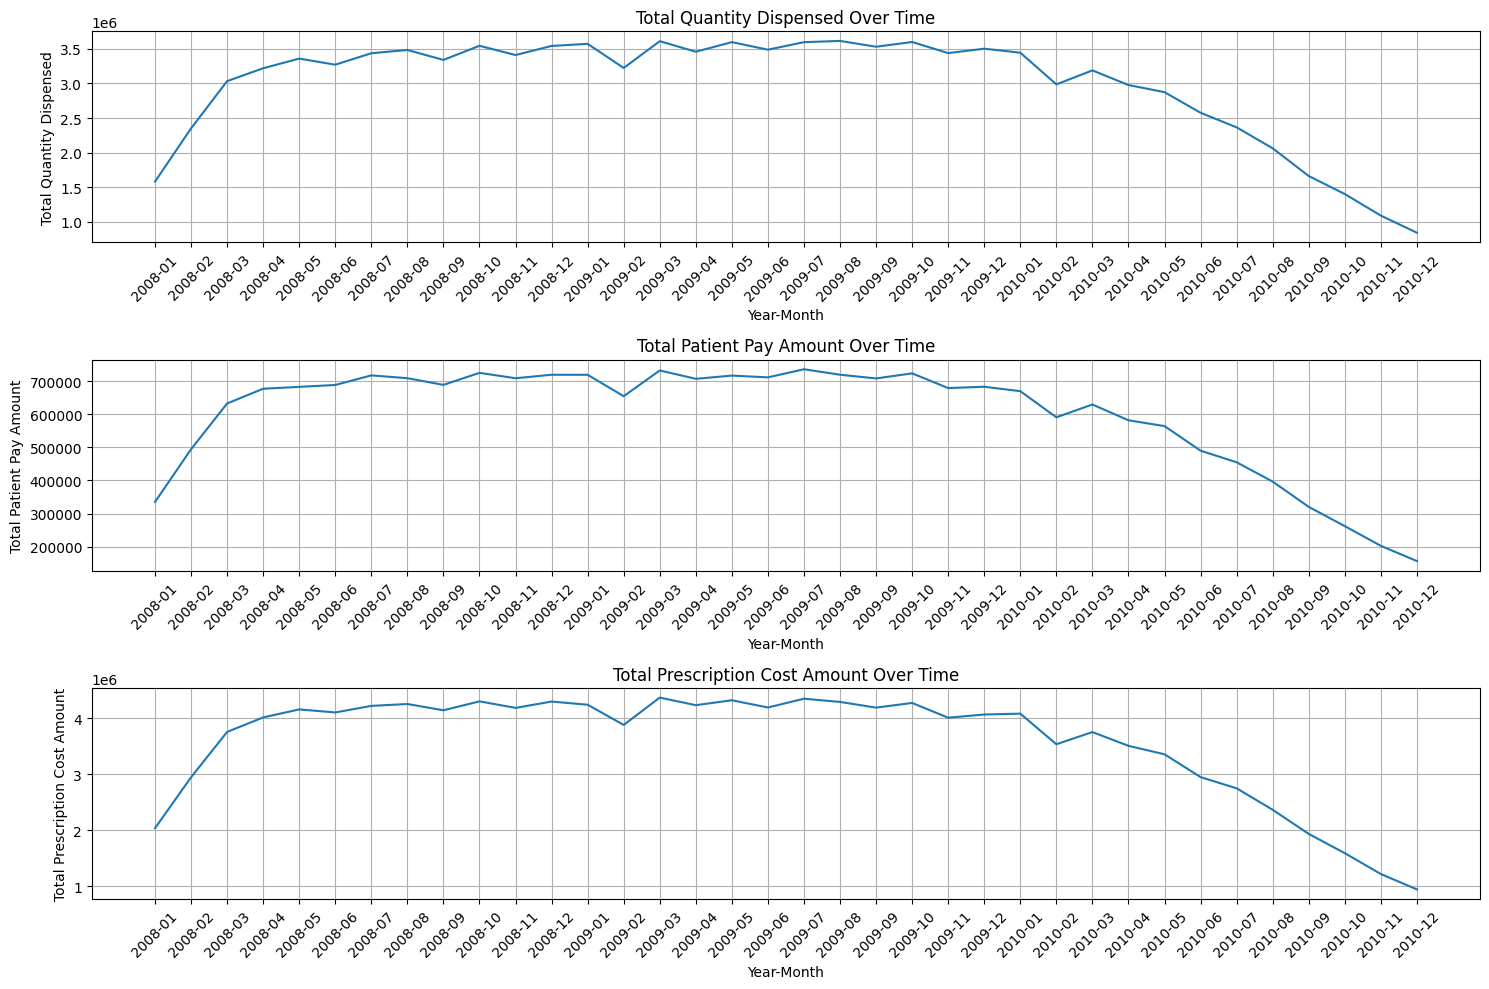

Monthly trends calculated and plotted.
   year  month  QTY_DSPNSD_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT year_month
0  2008      1       1581950.0      334860.0       2036370.0    2008-01
1  2008      2       2350910.0      494170.0       2946230.0    2008-02
2  2008      3       3032910.0      632450.0       3756090.0    2008-03
3  2008      4       3219220.0      676970.0       4015140.0    2008-04
4  2008      5       3358690.0      682600.0       4158370.0    2008-05


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and month and sum the relevant columns
df_monthly_trends = df.groupby(['year', 'month']).agg(
    QTY_DSPNSD_NUM=('QTY_DSPNSD_NUM', 'sum'),
    PTNT_PAY_AMT=('PTNT_PAY_AMT', 'sum'),
    TOT_RX_CST_AMT=('TOT_RX_CST_AMT', 'sum')
).reset_index()

# Combine year and month for plotting
df_monthly_trends['year_month'] = df_monthly_trends['year'].astype(str) + '-' + df_monthly_trends['month'].astype(str).str.zfill(2)

# Set figure size
plt.figure(figsize=(15, 10))

# Plot Total Quantity Dispensed over time
plt.subplot(3, 1, 1)
sns.lineplot(data=df_monthly_trends, x='year_month', y='QTY_DSPNSD_NUM')
plt.title('Total Quantity Dispensed Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Quantity Dispensed')
plt.xticks(rotation=45)
plt.grid(True)

# Plot Total Patient Pay Amount over time
plt.subplot(3, 1, 2)
sns.lineplot(data=df_monthly_trends, x='year_month', y='PTNT_PAY_AMT')
plt.title('Total Patient Pay Amount Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Patient Pay Amount')
plt.xticks(rotation=45)
plt.grid(True)

# Plot Total Prescription Cost Amount over time
plt.subplot(3, 1, 3)
sns.lineplot(data=df_monthly_trends, x='year_month', y='TOT_RX_CST_AMT')
plt.title('Total Prescription Cost Amount Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Prescription Cost Amount')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Monthly trends calculated and plotted.")
print(df_monthly_trends.head())


## Identify Frequently Prescribed Products

### Subtask:
Count the occurrences of each unique 'PROD_SRVC_ID' to determine the most frequently prescribed products. Display the top N products and visualize their distribution using bar charts. Additionally, analyze the average quantity dispensed and cost associated with these top products.


**Reasoning**:
I will count the occurrences of each unique 'PROD_SRVC_ID' to identify the most frequently prescribed products and then display the top 10 products along with their counts.



In [13]:
product_frequency = df['PROD_SRVC_ID'].value_counts().reset_index()
product_frequency.columns = ['PROD_SRVC_ID', 'Frequency']

top_10_products = product_frequency.head(10)
print('Top 10 Most Frequently Prescribed Products:')
print(top_10_products)


Top 10 Most Frequently Prescribed Products:
  PROD_SRVC_ID  Frequency
0  64378033202         69
1  58016090018         63
2  54868546601         63
3  65862005011         63
4  58016077792         62
5     37024110         61
6     78048634         61
7  58016042598         61
8  58016060618         60
9  66105050306         60


**Reasoning**:
I will visualize the top 10 most frequently prescribed products using a bar chart to show their distribution.



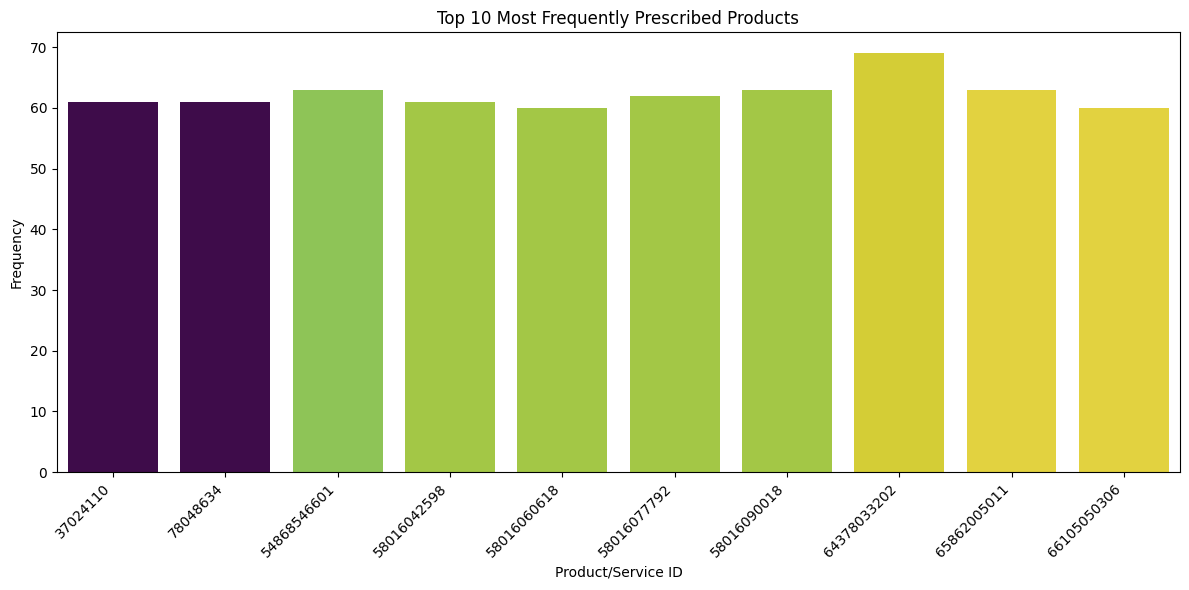

Bar chart of top 10 products displayed.


In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PROD_SRVC_ID', y='Frequency', data=top_10_products, hue='PROD_SRVC_ID', palette='viridis', legend=False)
plt.title('Top 10 Most Frequently Prescribed Products')
plt.xlabel('Product/Service ID')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar chart of top 10 products displayed.")

**Reasoning**:
Now that the top 10 most frequently prescribed products have been identified, the next step is to calculate the average quantity dispensed, patient pay amount, and total prescription cost for each of these products, as per the subtask instructions. This will provide further insights into the financial and usage patterns of these popular products.



In [16]:
merged_df = pd.merge(top_10_products, df, on='PROD_SRVC_ID', how='inner')

average_metrics_top_products = merged_df.groupby('PROD_SRVC_ID').agg(
    Avg_QTY_DSPNSD_NUM=('QTY_DSPNSD_NUM', 'mean'),
    Avg_PTNT_PAY_AMT=('PTNT_PAY_AMT', 'mean'),
    Avg_TOT_RX_CST_AMT=('TOT_RX_CST_AMT', 'mean')
).reset_index()

final_top_products_analysis = pd.merge(top_10_products, average_metrics_top_products, on='PROD_SRVC_ID', how='inner')

print('\nTop 10 Most Frequently Prescribed Products with Average Metrics:')
print(final_top_products_analysis)


Top 10 Most Frequently Prescribed Products with Average Metrics:
  PROD_SRVC_ID  Frequency  Avg_QTY_DSPNSD_NUM  Avg_PTNT_PAY_AMT  \
0  64378033202         69           37.391304         24.347826   
1  58016090018         63           46.507937         15.555556   
2  54868546601         63           50.476190         35.079365   
3  65862005011         63           38.571429         17.301587   
4  58016077792         62           35.483871         28.064516   
5     37024110         61           32.950820         23.114754   
6     78048634         61           36.229508         27.049180   
7  58016042598         61           46.885246         12.131148   
8  58016060618         60           39.333333         29.833333   
9  66105050306         60           48.333333         31.666667   

   Avg_TOT_RX_CST_AMT  
0           97.681159  
1           55.555556  
2           91.746032  
3           77.777778  
4           93.064516  
5           99.508197  
6           99.016393  
7   

## Analyze Patient Spending Patterns

### Subtask:
Group the data by 'DESYNPUF_ID' to calculate the total 'PTNT_PAY_AMT' and 'TOT_RX_CST_AMT' for each patient. Compute descriptive statistics for these patient-level costs and visualize their distributions using histograms to identify patients with high spending or specific spending behaviors.


**Reasoning**:
I will group the DataFrame by 'DESYNPUF_ID' and sum the 'PTNT_PAY_AMT' and 'TOT_RX_CST_AMT' to get patient-level spending data, as per the first instruction.



In [17]:
df_patient_spending = df.groupby('DESYNPUF_ID').agg(
    Total_PTNT_PAY_AMT=('PTNT_PAY_AMT', 'sum'),
    Total_TOT_RX_CST_AMT=('TOT_RX_CST_AMT', 'sum')
).reset_index()

print("Patient spending DataFrame created. Displaying head:")
print(df_patient_spending.head())

Patient spending DataFrame created. Displaying head:
        DESYNPUF_ID  Total_PTNT_PAY_AMT  Total_TOT_RX_CST_AMT
0  00013D2EFD8E45D1              2270.0               14360.0
1  00016F745862898F                60.0                2080.0
2  0001FDD721E223DC               760.0                3000.0
3  00021CA6FF03E670                30.0                 670.0
4  00024B3D2352D2D0               200.0                 220.0


**Reasoning**:
Now that the patient-level spending data is aggregated, I will compute the descriptive statistics for `Total_PTNT_PAY_AMT` and `Total_TOT_RX_CST_AMT` to understand their central tendency, dispersion, and shape of distribution, as per the second instruction.



In [18]:
print("\nDescriptive statistics for Total Patient Pay Amount:")
print(df_patient_spending['Total_PTNT_PAY_AMT'].describe())

print("\nDescriptive statistics for Total Prescription Cost Amount:")
print(df_patient_spending['Total_TOT_RX_CST_AMT'].describe())


Descriptive statistics for Total Patient Pay Amount:
count    37844.000000
mean       570.311542
std        642.660572
min          0.000000
25%         40.000000
50%        320.000000
75%        920.000000
max       3960.000000
Name: Total_PTNT_PAY_AMT, dtype: float64

Descriptive statistics for Total Prescription Cost Amount:
count    37844.000000
mean      3404.402547
std       4124.624030
min          0.000000
25%        280.000000
50%       1680.000000
75%       5070.000000
max      35360.000000
Name: Total_TOT_RX_CST_AMT, dtype: float64


# Task
**Reasoning**:
I will now visualize the distributions of `Total_PTNT_PAY_AMT` and `Total_TOT_RX_CST_AMT` using histograms to identify patients with high spending or specific spending behaviors, as per the subtask instructions. This will complement the descriptive statistics by providing a visual representation of the data's spread and identifying outliers.

**Action**:
Generate histograms for 'Total_PTNT_PAY_AMT' and 'Total_TOT_RX_CST_AMT' from the `df_patient_spending` DataFrame.
```python
plt.figure(figsize=(14, 6))

# Histogram for Total Patient Pay Amount
plt.subplot(1, 2, 1)
sns.histplot(df_patient_spending['Total_PTNT_PAY_AMT'], bins=50, kde=True)
plt.title('Distribution of Total Patient Pay Amount')
plt.xlabel('Total Patient Pay Amount')
plt.ylabel('Number of Patients')
plt.grid(True)

# Histogram for Total Prescription Cost Amount
plt.subplot(1, 2, 2)
sns.histplot(df_patient_spending['Total_TOT_RX_CST_AMT'], bins=50, kde=True)
plt.title('Distribution of Total Prescription Cost Amount')
plt.xlabel('Total Prescription Cost Amount')
plt.ylabel('Number of Patients')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Histograms for patient spending distributions displayed.")
```

## Identify Numerical Features

### Subtask:
Identify all numerical columns in the main DataFrame (`df`) that are relevant for correlation analysis. These typically include quantity, days supply, patient pay amount, total prescription cost, and the extracted year and month.


**Reasoning**:
I will select the specified numerical columns from the main DataFrame and create a new DataFrame called `df_numerical`.



In [19]:
df_numerical = df[['QTY_DSPNSD_NUM', 'DAYS_SUPLY_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT', 'year', 'month']].copy()
print("Numerical DataFrame for correlation analysis created. Displaying head:")
print(df_numerical.head())

Numerical DataFrame for correlation analysis created. Displaying head:
   QTY_DSPNSD_NUM  DAYS_SUPLY_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT  year  month
0            30.0            20.0          10.0           120.0  2008      1
1            10.0            10.0           0.0             0.0  2008      1
2           120.0            30.0          10.0           110.0  2008      1
3            30.0            30.0           0.0           240.0  2008      1
4            30.0            30.0          70.0            70.0  2008      1


**Reasoning**:
Now that the numerical columns have been identified, the next step is to calculate the correlation matrix between these features to understand their relationships. This directly follows the goal of correlation analysis.



In [20]:
correlation_matrix = df_numerical.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                QTY_DSPNSD_NUM  DAYS_SUPLY_NUM  PTNT_PAY_AMT  TOT_RX_CST_AMT  \
QTY_DSPNSD_NUM        1.000000        0.004736     -0.058272       -0.054456   
DAYS_SUPLY_NUM        0.004736        1.000000      0.029355       -0.000567   
PTNT_PAY_AMT         -0.058272        0.029355      1.000000        0.270449   
TOT_RX_CST_AMT       -0.054456       -0.000567      0.270449        1.000000   
year                  0.020735        0.022472     -0.002019       -0.001440   
month                 0.003770        0.004292     -0.000599       -0.002215   

                    year     month  
QTY_DSPNSD_NUM  0.020735  0.003770  
DAYS_SUPLY_NUM  0.022472  0.004292  
PTNT_PAY_AMT   -0.002019 -0.000599  
TOT_RX_CST_AMT -0.001440 -0.002215  
year            1.000000 -0.187168  
month          -0.187168  1.000000  


**Reasoning**:
I will visualize the correlation matrix using a heatmap to provide a clear and intuitive representation of the relationships between the numerical features, making it easier to identify strong or weak correlations. This is the final step in the correlation analysis.



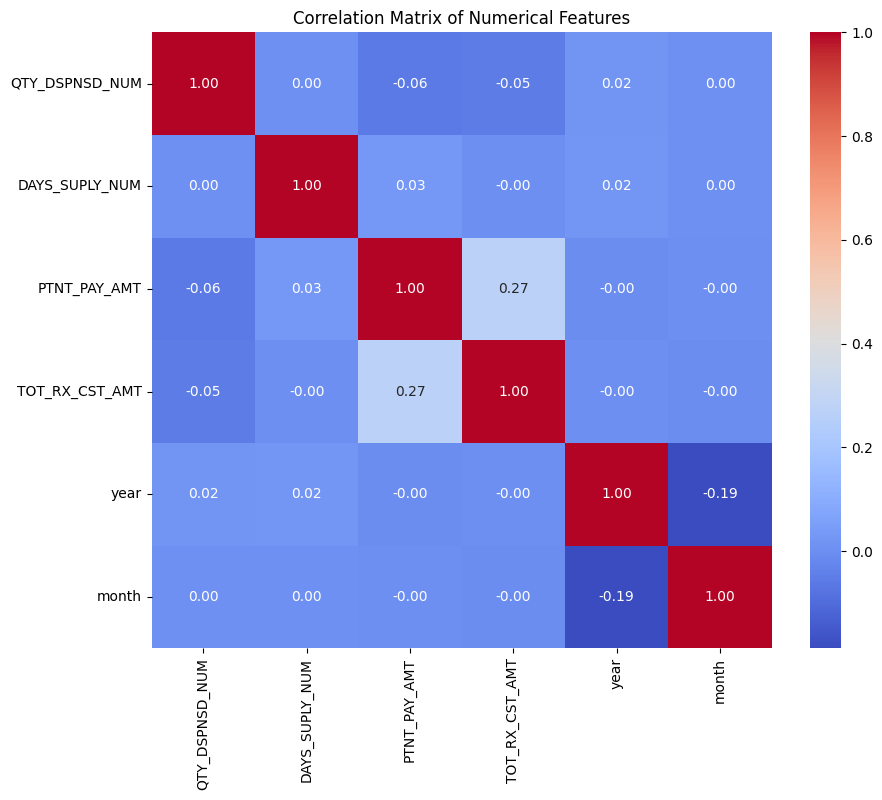

Heatmap of the correlation matrix displayed.


In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Heatmap of the correlation matrix displayed.")

## Final Task

### Subtask:
Summarize the findings from the correlation analysis, highlighting any strong positive or negative correlations between features.


## Summary:

### Data Analysis Key Findings

*   The correlation analysis focused on `QTY_DSPNSD_NUM`, `DAYS_SUPLY_NUM`, `PTNT_PAY_AMT`, `TOT_RX_CST_AMT`, `year`, and `month`.
*   A moderately positive correlation of approximately 0.27 was observed between `PTNT_PAY_AMT` (Patient Pay Amount) and `TOT_RX_CST_AMT` (Total Prescription Cost Amount), indicating that as the total cost of prescriptions increases, the patient's payment amount also tends to increase, although not very strongly.
*   Most other numerical features showed generally low correlations with each other, suggesting weak linear relationships. For example, `QTY_DSPNSD_NUM` and `DAYS_SUPLY_NUM` did not exhibit a strong linear relationship with the cost-related variables.

### Insights or Next Steps

*   Further investigation could explore non-linear relationships between variables or the impact of other categorical features on spending, as linear correlations were generally weak.
*   Given the moderate positive correlation between patient pay and total prescription cost, it would be beneficial to analyze the factors influencing the patient's portion of the payment relative to the total cost (e.g., insurance coverage, deductibles).


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================================================
# Config
# =========================================================

PDE_PATH = "DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"
NDC_MODELING_TABLE_PATH = None

OUTPUT_DIR = Path("late_refill_ml_dataset")

GROUPING_KEY = "NDC7"   # "NDC7" or "NDC8" or "NDC11"
GRACE_DAYS = 7

MIN_DAYS_SUPPLY = 1
MAX_DAYS_SUPPLY = 365

DROP_ZERO_COST_ROWS = False
USE_PATIENT_HISTORY_FEATURES = False
USE_NDC_MODELING_FEATURES = False
# cache controls
USE_STAGE1_CACHE = True
FORCE_REBUILD_STAGE1 = False

# stage-1 cached fill-level table path
STAGE1_CACHE_PATH = OUTPUT_DIR / f"prefeature_fill_level_{GROUPING_KEY.lower()}_grace{GRACE_DAYS}.parquet"


# =========================================================
# Helpers
# =========================================================

def normalize_ndc11(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )


def add_ndc_levels(df: pd.DataFrame, ndc11_col: str = "PROD_SRVC_ID") -> pd.DataFrame:
    out = df.copy()

    out[ndc11_col] = (
        out[ndc11_col]
        .astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )

    out["PROD_SRVC_ID"] = out[ndc11_col].astype("string")
    out["NDC11"] = out[ndc11_col].astype("string")
    out["NDC8"] = out["NDC11"].str[:8].astype("string")
    out["NDC7"] = out["NDC11"].str[:7].astype("string")
    return out


def to_datetime_yyyymmdd(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series.astype(str), format="%Y%m%d", errors="coerce")


def safe_divide(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    out = a / b
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def coerce_id_columns_to_string(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    id_like_cols = [
        "PROD_SRVC_ID",
        "NDC11",
        "NDC8",
        "NDC7",
        "PDE_ID",
        "DESYNPUF_ID",
        "next_pde_id",
    ]
    for col in id_like_cols:
        if col in out.columns:
            out[col] = out[col].astype("string")
    return out


def ensure_datetime_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")
    return out


def has_required_stage1_columns(df: pd.DataFrame, grouping_key: str) -> bool:
    required = {
        "DESYNPUF_ID",
        "PDE_ID",
        "SRVC_DT",
        "PROD_SRVC_ID",
        grouping_key,
        "QTY_DSPNSD_NUM",
        "DAYS_SUPPLY_NUM",
        "PTNT_PAY_AMT",
        "TOT_RX_CST_AMT",
        "qty_per_day",
        "patient_pay_share",
        "expected_runout_dt",
        "fill_index_in_chain",
        "chain_length",
        "next_fill_dt",
        "next_pde_id",
        "gap_days_to_next_fill",
        "days_late_vs_runout",
        "has_next_fill",
        "target_late_refill",
        "target_on_time_refill",
        "target_early_refill",
        "target_gap_days",
        "target_days_late",
        "is_last_fill_in_chain",
    }
    return required.issubset(df.columns)


# =========================================================
# Read and clean PDE
# =========================================================

def load_and_prepare_pde(pde_path: str) -> pd.DataFrame:
    df = pd.read_csv(
        pde_path,
        dtype={
            "DESYNPUF_ID": "string",
            "PDE_ID": "string",
            "PROD_SRVC_ID": "string",
        }
    )

    required = [
        "DESYNPUF_ID",
        "PDE_ID",
        "SRVC_DT",
        "PROD_SRVC_ID",
        "QTY_DSPNSD_NUM",
        "DAYS_SUPLY_NUM",
        "PTNT_PAY_AMT",
        "TOT_RX_CST_AMT",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required PDE columns: {missing}")

    df = add_ndc_levels(df, ndc11_col="PROD_SRVC_ID")

    df["SRVC_DT"] = to_datetime_yyyymmdd(df["SRVC_DT"])
    df["QTY_DSPNSD_NUM"] = pd.to_numeric(df["QTY_DSPNSD_NUM"], errors="coerce")
    df["DAYS_SUPPLY_NUM"] = pd.to_numeric(df["DAYS_SUPLY_NUM"], errors="coerce")
    df["PTNT_PAY_AMT"] = pd.to_numeric(df["PTNT_PAY_AMT"], errors="coerce")
    df["TOT_RX_CST_AMT"] = pd.to_numeric(df["TOT_RX_CST_AMT"], errors="coerce")

    df = df[df["SRVC_DT"].notna()].copy()
    df = df[df["DAYS_SUPPLY_NUM"].between(MIN_DAYS_SUPPLY, MAX_DAYS_SUPPLY, inclusive="both")].copy()

    if DROP_ZERO_COST_ROWS:
        df = df[
            (df["TOT_RX_CST_AMT"].fillna(0) > 0) |
            (df["PTNT_PAY_AMT"].fillna(0) > 0)
        ].copy()

    df["qty_per_day"] = safe_divide(df["QTY_DSPNSD_NUM"], df["DAYS_SUPPLY_NUM"])
    df["patient_pay_share"] = safe_divide(df["PTNT_PAY_AMT"], df["TOT_RX_CST_AMT"])
    df["expected_runout_dt"] = df["SRVC_DT"] + pd.to_timedelta(df["DAYS_SUPPLY_NUM"], unit="D")

    df = coerce_id_columns_to_string(df)
    return df


# =========================================================
# Build next-refill target
# =========================================================

def build_fill_level_target_table(
    df: pd.DataFrame,
    grouping_key: str = GROUPING_KEY,
    grace_days: int = GRACE_DAYS,
) -> pd.DataFrame:
    sort_cols = ["DESYNPUF_ID", grouping_key, "SRVC_DT", "PDE_ID"]
    work = df.sort_values(sort_cols).copy()

    group_cols = ["DESYNPUF_ID", grouping_key]

    work["fill_index_in_chain"] = work.groupby(group_cols).cumcount() + 1
    work["chain_length"] = work.groupby(group_cols)["PDE_ID"].transform("count")

    work["next_fill_dt"] = work.groupby(group_cols)["SRVC_DT"].shift(-1)
    work["next_pde_id"] = work.groupby(group_cols)["PDE_ID"].shift(-1).astype("string")

    work["gap_days_to_next_fill"] = (work["next_fill_dt"] - work["SRVC_DT"]).dt.days
    work["days_late_vs_runout"] = (work["next_fill_dt"] - work["expected_runout_dt"]).dt.days

    work["has_next_fill"] = work["next_fill_dt"].notna().astype(int)

    work["target_late_refill"] = np.where(
        work["next_fill_dt"].notna(),
        (work["days_late_vs_runout"] > grace_days).astype(int),
        np.nan,
    )

    work["target_on_time_refill"] = np.where(
        work["next_fill_dt"].notna(),
        ((work["days_late_vs_runout"] >= -grace_days) & (work["days_late_vs_runout"] <= grace_days)).astype(int),
        np.nan,
    )

    work["target_early_refill"] = np.where(
        work["next_fill_dt"].notna(),
        (work["days_late_vs_runout"] < -grace_days).astype(int),
        np.nan,
    )

    work["target_gap_days"] = np.where(
        work["next_fill_dt"].notna(),
        work["gap_days_to_next_fill"],
        np.nan,
    )

    work["target_days_late"] = np.where(
        work["next_fill_dt"].notna(),
        work["days_late_vs_runout"],
        np.nan,
    )

    work["is_last_fill_in_chain"] = (work["fill_index_in_chain"] == work["chain_length"]).astype(int)

    work = coerce_id_columns_to_string(work)
    return work


# =========================================================
# Stage-1 cache handling
# =========================================================

def load_stage1_cache(path: Path, grouping_key: str) -> pd.DataFrame:
    df = pd.read_parquet(path)

    df = coerce_id_columns_to_string(df)
    df = ensure_datetime_columns(df, ["SRVC_DT", "next_fill_dt", "expected_runout_dt"])

    if not has_required_stage1_columns(df, grouping_key):
        missing = sorted({
            "DESYNPUF_ID",
            "PDE_ID",
            "SRVC_DT",
            "PROD_SRVC_ID",
            grouping_key,
            "QTY_DSPNSD_NUM",
            "DAYS_SUPLY_NUM",
            "PTNT_PAY_AMT",
            "TOT_RX_CST_AMT",
            "qty_per_day",
            "patient_pay_share",
            "expected_runout_dt",
            "fill_index_in_chain",
            "chain_length",
            "next_fill_dt",
            "next_pde_id",
            "gap_days_to_next_fill",
            "days_late_vs_runout",
            "has_next_fill",
            "target_late_refill",
            "target_on_time_refill",
            "target_early_refill",
            "target_gap_days",
            "target_days_late",
            "is_last_fill_in_chain",
        } - set(df.columns))
        raise ValueError(f"Stage-1 cache exists but is missing required columns: {missing}")

    return df


def get_or_build_stage1_fill_table(
    pde_path: str,
    stage1_cache_path: Path,
    grouping_key: str,
    grace_days: int,
    use_cache: bool = True,
    force_rebuild: bool = False,
) -> pd.DataFrame:
    if use_cache and stage1_cache_path.exists() and not force_rebuild:
        print("[1/6] Loading stage-1 cached fill-level table ...")
        df = load_stage1_cache(stage1_cache_path, grouping_key=grouping_key)
        print(f"  Loaded stage-1 cache: {df.shape}")
        return df

    print("[1/6] Loading PDE...")
    pde = load_and_prepare_pde(pde_path)
    print(f"  PDE shape after cleaning: {pde.shape}")

    print("[2/6] Building next-refill targets...")
    fill_df = build_fill_level_target_table(
        pde,
        grouping_key=grouping_key,
        grace_days=grace_days,
    )
    print(f"  Fill-level table shape: {fill_df.shape}")

    stage1_cache_path.parent.mkdir(parents=True, exist_ok=True)
    fill_df.to_parquet(stage1_cache_path, index=False)
    print(f"  Saved stage-1 cache to: {stage1_cache_path}")

    return fill_df


# =========================================================
# Faster patient history features
# =========================================================

def add_patient_history_features_fast(df: pd.DataFrame, grouping_key: str = GROUPING_KEY) -> pd.DataFrame:
    work = df.sort_values(["DESYNPUF_ID", grouping_key, "SRVC_DT", "PDE_ID"]).copy()
    grp = work.groupby(["DESYNPUF_ID", grouping_key], sort=False)

    work["prev_fill_dt"] = grp["SRVC_DT"].shift(1)
    work["prev_days_supply"] = grp["DAYS_SUPPLY_NUM"].shift(1)
    work["prev_qty_dispensed"] = grp["QTY_DSPNSD_NUM"].shift(1)
    work["prev_patient_pay_amt"] = grp["PTNT_PAY_AMT"].shift(1)
    work["prev_total_rx_cost"] = grp["TOT_RX_CST_AMT"].shift(1)

    work["days_since_prev_fill"] = (work["SRVC_DT"] - work["prev_fill_dt"]).dt.days
    work["prev_expected_runout_dt"] = work["prev_fill_dt"] + pd.to_timedelta(work["prev_days_supply"], unit="D")
    work["prev_days_late_vs_runout"] = (work["SRVC_DT"] - work["prev_expected_runout_dt"]).dt.days

    work["prev_was_late"] = (work["prev_days_late_vs_runout"] > GRACE_DAYS).astype(float)
    work["prev_was_on_time"] = (
        (work["prev_days_late_vs_runout"] >= -GRACE_DAYS) &
        (work["prev_days_late_vs_runout"] <= GRACE_DAYS)
    ).astype(float)
    work["prev_was_early"] = (work["prev_days_late_vs_runout"] < -GRACE_DAYS).astype(float)

    work["n_prior_fills_in_chain"] = work["fill_index_in_chain"] - 1
    prior_n = work["n_prior_fills_in_chain"].astype(float)

    # historical means using cumulative sums over prior rows only
    for src_col, out_col in [
        ("DAYS_SUPPLY_NUM", "hist_mean_days_supply"),
        ("qty_per_day", "hist_mean_qty_per_day"),
        ("days_since_prev_fill", "hist_mean_gap_from_prev_fill"),
        ("prev_days_late_vs_runout", "hist_mean_prev_days_late"),
        ("prev_was_late", "hist_late_rate"),
        ("prev_was_on_time", "hist_on_time_rate"),
        ("prev_was_early", "hist_early_rate"),
    ]:
        csum = grp[src_col].cumsum() - work[src_col]
        work[out_col] = csum / prior_n.replace(0, np.nan)

    # std for days supply from prior rows only
    # std = sqrt((sum_x2 - sum_x^2 / n) / (n - 1))
    x = work["DAYS_SUPPLY_NUM"].astype(float)
    csum_x = grp["DAYS_SUPPLY_NUM"].cumsum() - x
    csum_x2 = grp["DAYS_SUPPLY_NUM"].transform(lambda s: (s.astype(float) ** 2).cumsum()) - (x ** 2)

    denom = (prior_n - 1).replace(0, np.nan)
    variance = (csum_x2 - (csum_x ** 2) / prior_n.replace(0, np.nan)) / denom
    work["hist_std_days_supply"] = np.sqrt(variance.clip(lower=0))

    return work


# =========================================================
# Simple engineered features
# =========================================================

def add_simple_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["service_year"] = out["SRVC_DT"].dt.year
    out["service_month"] = out["SRVC_DT"].dt.month
    out["service_day"] = out["SRVC_DT"].dt.day
    out["service_dayofweek"] = out["SRVC_DT"].dt.dayofweek
    out["service_quarter"] = out["SRVC_DT"].dt.quarter
    out["is_month_start"] = out["SRVC_DT"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["SRVC_DT"].dt.is_month_end.astype(int)

    out["days_supply_30"] = (out["DAYS_SUPPLY_NUM"] == 30).astype(int)
    out["days_supply_60"] = (out["DAYS_SUPPLY_NUM"] == 60).astype(int)
    out["days_supply_90"] = (out["DAYS_SUPPLY_NUM"] == 90).astype(int)
    out["days_supply_short"] = (out["DAYS_SUPPLY_NUM"] < 28).astype(int)
    out["days_supply_long"] = (out["DAYS_SUPPLY_NUM"] > 90).astype(int)

    out["log_days_supply"] = np.log1p(out["DAYS_SUPPLY_NUM"])
    out["log_qty_dispensed"] = np.log1p(out["QTY_DSPNSD_NUM"].clip(lower=0))
    out["log_total_rx_cost"] = np.log1p(out["TOT_RX_CST_AMT"].clip(lower=0))
    out["log_patient_pay_amt"] = np.log1p(out["PTNT_PAY_AMT"].clip(lower=0))

    return out


# =========================================================
# Merge NDC modeling features
# =========================================================

def load_ndc_modeling_features(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Missing modeling feature file: {path}")

    if p.suffix == ".parquet":
        df = pd.read_parquet(p)
    elif p.suffix == ".csv":
        df = pd.read_csv(p)
    else:
        raise ValueError(f"Unsupported file type: {p.suffix}")

    for col in ["PROD_SRVC_ID", "NDC11", "NDC8", "NDC7", "DESYNPUF_ID", "PDE_ID"]:
        if col in df.columns:
            df[col] = df[col].astype("string")

    return df.copy()


def merge_ndc_modeling_features(fill_df: pd.DataFrame, ndc_feat_df: pd.DataFrame) -> pd.DataFrame:
    out = fill_df.copy()

    keep_cols = [c for c in ndc_feat_df.columns if c != "DESYNPUF_ID"]
    ndc_feat_df = ndc_feat_df[keep_cols].copy()

    for col in ["PROD_SRVC_ID", "NDC11", "NDC8", "NDC7"]:
        if col in out.columns:
            out[col] = out[col].astype("string")
        if col in ndc_feat_df.columns:
            ndc_feat_df[col] = ndc_feat_df[col].astype("string")

    available = [c for c in ["PROD_SRVC_ID", "NDC11", "NDC8", "NDC7"] if c in out.columns and c in ndc_feat_df.columns]
    if not available:
        raise ValueError("No common join columns between fill table and NDC modeling features.")

    if "PROD_SRVC_ID" in available:
        key = ["PROD_SRVC_ID"]
    elif "NDC11" in available:
        key = ["NDC11"]
    elif "NDC8" in available:
        key = ["NDC8"]
    else:
        key = ["NDC7"]

    ndc_feat_df = ndc_feat_df.drop_duplicates(subset=key)
    merged = out.merge(ndc_feat_df, on=key, how="left")
    merged = coerce_id_columns_to_string(merged)
    return merged


# =========================================================
# Final dataset builder
# =========================================================

def build_late_refill_ml_dataset(
    pde_path: str = PDE_PATH,
    ndc_modeling_table_path: str = NDC_MODELING_TABLE_PATH,
    stage1_cache_path: Path = STAGE1_CACHE_PATH,
    grouping_key: str = GROUPING_KEY,
    grace_days: int = GRACE_DAYS,
    output_dir: Path = OUTPUT_DIR,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)

    ml = get_or_build_stage1_fill_table(
        pde_path=pde_path,
        stage1_cache_path=stage1_cache_path,
        grouping_key=grouping_key,
        grace_days=grace_days,
        use_cache=USE_STAGE1_CACHE,
        force_rebuild=FORCE_REBUILD_STAGE1,
    )

    if stage1_cache_path.exists() and USE_STAGE1_CACHE and not FORCE_REBUILD_STAGE1:
        print("[2/6] Skipping raw PDE rebuild because stage-1 cache is available.")

    print("[3/6] Adding simple features...")
    ml = add_simple_features(ml)

    if USE_PATIENT_HISTORY_FEATURES:
        print("[4/6] Adding patient history features (fast cached version)...")
        ml = add_patient_history_features_fast(ml, grouping_key=grouping_key)
    else:
        print("[4/6] Skipping patient history features...")

    if USE_NDC_MODELING_FEATURES and ndc_modeling_table_path is not None and Path(ndc_modeling_table_path).exists():
        print("[5/6] Merging NDC modeling features...")
        ndc_feat = load_ndc_modeling_features(ndc_modeling_table_path)
        ml = merge_ndc_modeling_features(ml, ndc_feat)
        print(f"  After NDC merge: {ml.shape}")
    else:
        print("[5/6] Skipping NDC modeling feature merge...")
    print("[6/6] Building trainable subsets...")
    trainable = ml[ml["has_next_fill"] == 1].copy()

    clf_df = trainable[trainable["target_late_refill"].notna()].copy()
    clf_df["target_late_refill"] = clf_df["target_late_refill"].astype(int)

    reg_df = trainable[trainable["target_days_late"].notna()].copy()

    leakage_or_nonfeature_cols = {
        "next_fill_dt",
        "next_pde_id",
        "gap_days_to_next_fill",
        "days_late_vs_runout",
        "target_late_refill",
        "target_on_time_refill",
        "target_early_refill",
        "target_gap_days",
        "target_days_late",
        "has_next_fill",
        "expected_runout_dt",
        "prev_expected_runout_dt",
    }

    feature_cols = [c for c in clf_df.columns if c not in leakage_or_nonfeature_cols]

    with open(output_dir / f"feature_columns_{grouping_key.lower()}.txt", "w", encoding="utf-8") as f:
        for col in feature_cols:
            f.write(col + "\n")

    ml = coerce_id_columns_to_string(ml)
    clf_df = coerce_id_columns_to_string(clf_df)
    reg_df = coerce_id_columns_to_string(reg_df)

    ml.to_parquet(output_dir / f"fill_level_dataset_all_{grouping_key.lower()}.parquet", index=False)
    clf_df.to_parquet(output_dir / f"late_refill_classification_{grouping_key.lower()}.parquet", index=False)
    reg_df.to_parquet(output_dir / f"late_refill_regression_{grouping_key.lower()}.parquet", index=False)

    clf_df.head(5000).to_csv(
        output_dir / f"late_refill_classification_sample_{grouping_key.lower()}.csv",
        index=False
    )

    summary = pd.DataFrame([{
        "grouping_key": grouping_key,
        "grace_days": grace_days,
        "n_all_fill_rows": len(ml),
        "n_trainable_rows": len(trainable),
        "n_classification_rows": len(clf_df),
        "late_rate": clf_df["target_late_refill"].mean() if len(clf_df) else np.nan,
        "mean_target_days_late": reg_df["target_days_late"].mean() if len(reg_df) else np.nan,
        "median_target_days_late": reg_df["target_days_late"].median() if len(reg_df) else np.nan,
        "n_feature_columns": len(feature_cols),
        "n_patients": clf_df["DESYNPUF_ID"].nunique() if "DESYNPUF_ID" in clf_df.columns else np.nan,
        "n_unique_groups": clf_df[grouping_key].nunique() if grouping_key in clf_df.columns else np.nan,
    }])
    summary.to_csv(output_dir / f"dataset_summary_{grouping_key.lower()}.csv", index=False)

    print("\nDone.")
    print(summary.to_string(index=False))
    print(f"\nSaved to: {output_dir.resolve()}")

    return clf_df, reg_df


# =========================================================
# Run
# =========================================================

classification_df, regression_df = build_late_refill_ml_dataset(
    pde_path=PDE_PATH,
    ndc_modeling_table_path=NDC_MODELING_TABLE_PATH,
    stage1_cache_path=STAGE1_CACHE_PATH,
    grouping_key=GROUPING_KEY,
    grace_days=GRACE_DAYS,
    output_dir=OUTPUT_DIR,
)

print("\nClassification preview:")
print(classification_df.head(10).to_string(index=False))

[1/6] Loading PDE...
  PDE shape after cleaning: (5434695, 15)
[2/6] Building next-refill targets...
  Fill-level table shape: (5434695, 28)
  Saved stage-1 cache to: late_refill_ml_dataset/prefeature_fill_level_ndc7_grace7.parquet
[2/6] Skipping raw PDE rebuild because stage-1 cache is available.
[3/6] Adding simple features...
[4/6] Skipping patient history features...
[5/6] Skipping NDC modeling feature merge...
[6/6] Building trainable subsets...

Done.
grouping_key  grace_days  n_all_fill_rows  n_trainable_rows  n_classification_rows  late_rate  mean_target_days_late  median_target_days_late  n_feature_columns  n_patients  n_unique_groups
        NDC7           7          5434695            364262                 364262   0.874599             226.710445                    175.0                 33       54944             4104

Saved to: /content/late_refill_ml_dataset

Classification preview:
     DESYNPUF_ID          PDE_ID    SRVC_DT PROD_SRVC_ID  QTY_DSPNSD_NUM  DAYS_SUPLY_NUM  

for time split - patient held out

In [25]:

from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================

DATA_PATH = "late_refill_ml_dataset/late_refill_classification_ndc7.parquet"
OUTPUT_DIR = Path("late_refill_model_compare_ndc7")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_late_refill"
DATE_COL = "SRVC_DT"
PATIENT_COL = "DESYNPUF_ID"
ID_COLS_TO_KEEP_IN_OUTPUT = ["DESYNPUF_ID", "PDE_ID", "SRVC_DT"]

#VALIDATION_SCHEME = "time_split_only"
VALIDATION_SCHEME = "time_split_plus_patient_holdout"

USE_EXPLICIT_SPLIT_DATE = False
EXPLICIT_SPLIT_DATE = "2009-07-01"

MODEL_NAMES = ["xgboost", "lightgbm"]


# =========================================================
# Data loading
# =========================================================

df = pd.read_parquet(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df[df[DATE_COL].notna()].copy()

print("Loaded shape:", df.shape)
print("Target rate:", df[TARGET_COL].mean())
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())

# already handled in dataset creation, but keep explicit sanity check
if "has_next_fill" in df.columns:
    print("Unique has_next_fill values:", sorted(df["has_next_fill"].dropna().unique().tolist()))


# =========================================================
# Split helpers
# =========================================================

def build_split(model_df: pd.DataFrame, validation_scheme: str):
    model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

    if USE_EXPLICIT_SPLIT_DATE:
        split_date = pd.Timestamp(EXPLICIT_SPLIT_DATE)
    else:
        split_idx = int(len(model_df) * 0.8)
        split_date = model_df.loc[split_idx, DATE_COL]

    candidate_train = model_df.loc[model_df[DATE_COL] < split_date].copy()
    candidate_valid = model_df.loc[model_df[DATE_COL] >= split_date].copy()

    if validation_scheme == "time_split_only":
        train_df = candidate_train.copy()
        valid_df = candidate_valid.copy()

    elif validation_scheme == "time_split_plus_patient_holdout":
        valid_patients = set(candidate_valid[PATIENT_COL].astype(str).unique())
        train_df = candidate_train.loc[
            ~candidate_train[PATIENT_COL].astype(str).isin(valid_patients)
        ].copy()
        valid_df = candidate_valid.copy()

        if len(train_df) == 0:
            raise ValueError("Training set became empty after patient holdout. Use an earlier split date.")

        overlap = set(train_df[PATIENT_COL].astype(str)).intersection(set(valid_df[PATIENT_COL].astype(str)))
        if len(overlap) != 0:
            raise ValueError("Patient overlap still exists after patient holdout.")

    else:
        raise ValueError("Unknown VALIDATION_SCHEME")

    return split_date, candidate_train, candidate_valid, train_df, valid_df


split_date, candidate_train, candidate_valid, train_df, valid_df = build_split(df, VALIDATION_SCHEME)

shared_patients = len(
    set(train_df[PATIENT_COL].astype(str)).intersection(set(valid_df[PATIENT_COL].astype(str)))
)

print("\nValidation scheme:", VALIDATION_SCHEME)
print("Split date:", split_date)
print("Candidate train rows:", len(candidate_train))
print("Candidate valid rows:", len(candidate_valid))
print("Final train rows:", len(train_df))
print("Final valid rows:", len(valid_df))
print("Train target rate:", train_df[TARGET_COL].mean())
print("Valid target rate:", valid_df[TARGET_COL].mean())
print("Shared patients across train/valid:", shared_patients)


# =========================================================
# Feature prep
# =========================================================

drop_cols = {
    TARGET_COL,
    "target_on_time_refill",
    "target_early_refill",
    "target_gap_days",
    "target_days_late",
    "has_next_fill",
    "next_fill_dt",
    "next_pde_id",
    "gap_days_to_next_fill",
    "days_late_vs_runout",
    "expected_runout_dt",
    "prev_expected_runout_dt",
    "DESYNPUF_ID",
    "PDE_ID",
}

y_train = train_df[TARGET_COL].astype(int)
y_valid = valid_df[TARGET_COL].astype(int)

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns], errors="ignore").copy()
X_valid = valid_df.drop(columns=[c for c in drop_cols if c in valid_df.columns], errors="ignore").copy()

# keep date only for splitting, not modeling
X_train = X_train.drop(columns=[DATE_COL], errors="ignore")
X_valid = X_valid.drop(columns=[DATE_COL], errors="ignore")

categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("\nNumeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),
    ],
    remainder="drop"
)


# =========================================================
# Model factory
# =========================================================

def make_model(model_name: str):
    if model_name == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )

    if model_name == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )

    raise ValueError(f"Unsupported model_name: {model_name}")


# =========================================================
# Train + evaluate loop
# =========================================================

comparison_rows = []

for model_name in MODEL_NAMES:
    print(f"\n{'=' * 70}")
    print(f"Training model: {model_name}")
    print(f"{'=' * 70}")

    model_output_dir = OUTPUT_DIR / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    clf = Pipeline([
        ("prep", preprocessor),
        ("model", make_model(model_name)),
    ])

    clf.fit(X_train, y_train)

    valid_proba = clf.predict_proba(X_valid)[:, 1]

    best_threshold = 0.5
    best_f1 = -1.0
    for thr in np.arange(0.10, 0.91, 0.01):
        pred = (valid_proba >= thr).astype(int)
        score = f1_score(y_valid, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = thr

    valid_pred = (valid_proba >= best_threshold).astype(int)

    metrics = {
        "validation_scheme": VALIDATION_SCHEME,
        "model_type": model_name,
        "split_date": str(split_date),
        "n_candidate_train": int(len(candidate_train)),
        "n_candidate_valid": int(len(candidate_valid)),
        "n_train_final": int(len(train_df)),
        "n_valid_final": int(len(valid_df)),
        "train_positive_rate": float(y_train.mean()),
        "valid_positive_rate": float(y_valid.mean()),
        "shared_patients_train_valid": int(shared_patients),
        "auroc": float(roc_auc_score(y_valid, valid_proba)),
        "pr_auc": float(average_precision_score(y_valid, valid_proba)),
        "f1": float(f1_score(y_valid, valid_pred, zero_division=0)),
        "best_threshold": float(best_threshold),
    }

    print(json.dumps(metrics, indent=2))

    # save predictions
    pred_cols = [c for c in ID_COLS_TO_KEEP_IN_OUTPUT if c in valid_df.columns] + [TARGET_COL]
    preds_out = valid_df[pred_cols].copy()
    preds_out["pred_proba"] = valid_proba
    preds_out["pred_label"] = valid_pred
    preds_out["threshold"] = best_threshold

    preds_out.to_parquet(model_output_dir / "validation_predictions.parquet", index=False)
    preds_out.to_csv(model_output_dir / "validation_predictions.csv", index=False)

    # save feature importance
    feature_names = clf.named_steps["prep"].get_feature_names_out()
    model_obj = clf.named_steps["model"]

    if hasattr(model_obj, "feature_importances_"):
        feat_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model_obj.feature_importances_,
        }).sort_values("importance", ascending=False)
    else:
        feat_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": np.nan,
        })

    feat_imp.to_csv(model_output_dir / "feature_importance.csv", index=False)

    print("\nTop 20 features:")
    print(feat_imp.head(20).to_string(index=False))

    # save model
    with open(model_output_dir / "model.pkl", "wb") as f:
        pickle.dump(clf, f)

    with open(model_output_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    comparison_rows.append(metrics)

# =========================================================
# Comparison table
# =========================================================

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["pr_auc", "auroc", "f1"], ascending=False
).reset_index(drop=True)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
comparison_df.to_json(OUTPUT_DIR / "model_comparison.json", orient="records", indent=2)

print(f"\n{'=' * 70}")
print("Model comparison")
print(f"{'=' * 70}")
print(comparison_df[[
    "model_type",
    "validation_scheme",
    "auroc",
    "pr_auc",
    "f1",
    "best_threshold",
    "n_train_final",
    "n_valid_final",
    "shared_patients_train_valid",
]].to_string(index=False))

print(f"\nSaved outputs to: {OUTPUT_DIR.resolve()}")

Loaded shape: (364262, 44)
Target rate: 0.8745985032751151
Date range: 2008-01-01 00:00:00 to 2010-12-30 00:00:00
Unique has_next_fill values: [1]

Validation scheme: time_split_plus_patient_holdout
Split date: 2009-07-30 00:00:00
Candidate train rows: 291372
Candidate valid rows: 72890
Final train rows: 81575
Final valid rows: 72890
Train target rate: 0.8927980386147717
Valid target rate: 0.7745918507339827
Shared patients across train/valid: 0

Numeric features: 26
Categorical features: 4

Training model: xgboost
{
  "validation_scheme": "time_split_plus_patient_holdout",
  "model_type": "xgboost",
  "split_date": "2009-07-30 00:00:00",
  "n_candidate_train": 291372,
  "n_candidate_valid": 72890,
  "n_train_final": 81575,
  "n_valid_final": 72890,
  "train_positive_rate": 0.8927980386147717,
  "valid_positive_rate": 0.7745918507339827,
  "shared_patients_train_valid": 0,
  "auroc": 0.6125059683855056,
  "pr_auc": 0.8323306130316355,
  "f1": 0.8730820714788651,
  "best_threshold": 0.1

In [ ]:

from pathlib import Path
import numpy as np
import pandas as pd

# =========================================================
# Config
# =========================================================

PDE_PATH = "DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"
OUTPUT_DIR = Path("late_refill_ml_dataset_enriched")

GROUPING_KEY = "NDC7"   # use NDC7 as your main grouping now
GRACE_DAYS = 7

MIN_DAYS_SUPPLY = 1
MAX_DAYS_SUPPLY = 365

DROP_ZERO_COST_ROWS = False

USE_STAGE1_CACHE = True
FORCE_REBUILD_STAGE1 = False
USE_POLYPHARMACY_FEATURES = True

STAGE1_CACHE_PATH = Path("late_refill_ml_dataset") / f"prefeature_fill_level_{GROUPING_KEY.lower()}_grace{GRACE_DAYS}.parquet"


# =========================================================
# Helpers
# =========================================================

def normalize_ndc11(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )


def add_ndc_levels(df: pd.DataFrame, ndc11_col: str = "PROD_SRVC_ID") -> pd.DataFrame:
    out = df.copy()
    out[ndc11_col] = (
        out[ndc11_col]
        .astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )
    out["PROD_SRVC_ID"] = out[ndc11_col].astype("string")
    out["NDC11"] = out[ndc11_col].astype("string")
    out["NDC8"] = out["NDC11"].str[:8].astype("string")
    out["NDC7"] = out["NDC11"].str[:7].astype("string")
    return out


def to_datetime_yyyymmdd(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series.astype(str), format="%Y%m%d", errors="coerce")


def safe_divide(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    out = a / b
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def coerce_id_columns_to_string(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in [
        "DESYNPUF_ID",
        "PDE_ID",
        "PROD_SRVC_ID",
        "NDC11",
        "NDC8",
        "NDC7",
        "next_pde_id",
    ]:
        if col in out.columns:
            out[col] = out[col].astype("string")
    return out


def ensure_datetime_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")
    return out


# =========================================================
# Raw PDE -> stage 1
# =========================================================

def load_and_prepare_pde(pde_path: str) -> pd.DataFrame:
    df = pd.read_csv(
        pde_path,
        usecols=[
            "DESYNPUF_ID",
            "PDE_ID",
            "SRVC_DT",
            "PROD_SRVC_ID",
            "QTY_DSPNSD_NUM",
            "DAYS_SUPLY_NUM",
            "PTNT_PAY_AMT",
            "TOT_RX_CST_AMT",
        ],
        dtype={
            "DESYNPUF_ID": "string",
            "PDE_ID": "string",
            "PROD_SRVC_ID": "string",
        }
    )

    required = [
        "DESYNPUF_ID",
        "PDE_ID",
        "SRVC_DT",
        "PROD_SRVC_ID",
        "QTY_DSPNSD_NUM",
        "DAYS_SUPLY_NUM",
        "PTNT_PAY_AMT",
        "TOT_RX_CST_AMT",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required PDE columns: {missing}")

    df = add_ndc_levels(df, ndc11_col="PROD_SRVC_ID")

    df["SRVC_DT"] = to_datetime_yyyymmdd(df["SRVC_DT"])
    df["QTY_DSPNSD_NUM"] = pd.to_numeric(df["QTY_DSPNSD_NUM"], errors="coerce")
    df["DAYS_SUPLY_NUM"] = pd.to_numeric(df["DAYS_SUPLY_NUM"], errors="coerce")
    df["PTNT_PAY_AMT"] = pd.to_numeric(df["PTNT_PAY_AMT"], errors="coerce")
    df["TOT_RX_CST_AMT"] = pd.to_numeric(df["TOT_RX_CST_AMT"], errors="coerce")

    df = df[df["SRVC_DT"].notna()].copy()
    df = df[df["DAYS_SUPLY_NUM"].between(MIN_DAYS_SUPPLY, MAX_DAYS_SUPPLY, inclusive="both")].copy()

    if DROP_ZERO_COST_ROWS:
        df = df[
            (df["TOT_RX_CST_AMT"].fillna(0) > 0) |
            (df["PTNT_PAY_AMT"].fillna(0) > 0)
        ].copy()

    df["qty_per_day"] = safe_divide(df["QTY_DSPNSD_NUM"], df["DAYS_SUPLY_NUM"])
    df["patient_pay_share"] = safe_divide(df["PTNT_PAY_AMT"], df["TOT_RX_CST_AMT"])
    df["expected_runout_dt"] = df["SRVC_DT"] + pd.to_timedelta(df["DAYS_SUPLY_NUM"], unit="D")

    df = coerce_id_columns_to_string(df)
    return df


def build_fill_level_target_table(df: pd.DataFrame, grouping_key: str, grace_days: int) -> pd.DataFrame:
    sort_cols = ["DESYNPUF_ID", grouping_key, "SRVC_DT", "PDE_ID"]
    work = df.sort_values(sort_cols).copy()

    group_cols = ["DESYNPUF_ID", grouping_key]

    work["fill_index_in_chain"] = work.groupby(group_cols).cumcount() + 1
    work["chain_length"] = work.groupby(group_cols)["PDE_ID"].transform("count")

    work["next_fill_dt"] = work.groupby(group_cols)["SRVC_DT"].shift(-1)
    work["next_pde_id"] = work.groupby(group_cols)["PDE_ID"].shift(-1).astype("string")

    work["gap_days_to_next_fill"] = (work["next_fill_dt"] - work["SRVC_DT"]).dt.days
    work["days_late_vs_runout"] = (work["next_fill_dt"] - work["expected_runout_dt"]).dt.days

    work["has_next_fill"] = work["next_fill_dt"].notna().astype(int)

    work["target_late_refill"] = np.where(
        work["next_fill_dt"].notna(),
        (work["days_late_vs_runout"] > grace_days).astype(int),
        np.nan,
    )

    work["target_on_time_refill"] = np.where(
        work["next_fill_dt"].notna(),
        ((work["days_late_vs_runout"] >= -grace_days) & (work["days_late_vs_runout"] <= grace_days)).astype(int),
        np.nan,
    )

    work["target_early_refill"] = np.where(
        work["next_fill_dt"].notna(),
        (work["days_late_vs_runout"] < -grace_days).astype(int),
        np.nan,
    )

    work["target_gap_days"] = np.where(
        work["next_fill_dt"].notna(),
        work["gap_days_to_next_fill"],
        np.nan,
    )

    work["target_days_late"] = np.where(
        work["next_fill_dt"].notna(),
        work["days_late_vs_runout"],
        np.nan,
    )

    work["is_last_fill_in_chain"] = (work["fill_index_in_chain"] == work["chain_length"]).astype(int)

    work = coerce_id_columns_to_string(work)
    return work


def load_stage1_cache(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df = coerce_id_columns_to_string(df)
    df = ensure_datetime_columns(df, ["SRVC_DT", "next_fill_dt", "expected_runout_dt"])
    return df


def get_or_build_stage1_fill_table(
    pde_path: str,
    stage1_cache_path: Path,
    grouping_key: str,
    grace_days: int,
    use_cache: bool = True,
    force_rebuild: bool = False,
) -> pd.DataFrame:
    if use_cache and stage1_cache_path.exists() and not force_rebuild:
        print("[1/7] Loading stage-1 cache ...")
        df = load_stage1_cache(stage1_cache_path)
        print("  Loaded:", df.shape)
        return df

    print("[1/7] Loading PDE ...")
    pde = load_and_prepare_pde(pde_path)
    print("  PDE shape:", pde.shape)

    print("[2/7] Building target table ...")
    fill_df = build_fill_level_target_table(pde, grouping_key=grouping_key, grace_days=grace_days)
    print("  Fill-level shape:", fill_df.shape)

    stage1_cache_path.parent.mkdir(parents=True, exist_ok=True)
    fill_df.to_parquet(stage1_cache_path, index=False)
    print("  Saved stage-1 cache to:", stage1_cache_path)

    return fill_df


# =========================================================
# Simple date and current-fill features
# =========================================================

def add_simple_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["service_year"] = out["SRVC_DT"].dt.year
    out["service_month"] = out["SRVC_DT"].dt.month
    out["service_day"] = out["SRVC_DT"].dt.day
    out["service_dayofweek"] = out["SRVC_DT"].dt.dayofweek
    out["service_quarter"] = out["SRVC_DT"].dt.quarter
    out["is_month_start"] = out["SRVC_DT"].dt.is_month_start.astype(int)
    out["is_month_end"] = out["SRVC_DT"].dt.is_month_end.astype(int)

    out["month_sin"] = np.sin(2 * np.pi * out["service_month"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["service_month"] / 12.0)

    out["days_supply_30"] = (out["DAYS_SUPLY_NUM"] == 30).astype(int)
    out["days_supply_60"] = (out["DAYS_SUPLY_NUM"] == 60).astype(int)
    out["days_supply_90"] = (out["DAYS_SUPLY_NUM"] == 90).astype(int)
    out["days_supply_short"] = (out["DAYS_SUPLY_NUM"] < 28).astype(int)
    out["days_supply_long"] = (out["DAYS_SUPLY_NUM"] > 90).astype(int)

    out["log_days_supply"] = np.log1p(out["DAYS_SUPLY_NUM"])
    out["log_qty_dispensed"] = np.log1p(out["QTY_DSPNSD_NUM"].clip(lower=0))
    out["log_total_rx_cost"] = np.log1p(out["TOT_RX_CST_AMT"].clip(lower=0))
    out["log_patient_pay_amt"] = np.log1p(out["PTNT_PAY_AMT"].clip(lower=0))

    return out


# =========================================================
# Core within-chain history features
# =========================================================

def add_enriched_chain_features(df: pd.DataFrame, grouping_key: str, grace_days: int) -> pd.DataFrame:
    work = df.sort_values(["DESYNPUF_ID", grouping_key, "SRVC_DT", "PDE_ID"]).copy()
    grp = work.groupby(["DESYNPUF_ID", grouping_key], sort=False)

    # lag features
    work["prev_fill_dt"] = grp["SRVC_DT"].shift(1)
    work["prev_days_supply"] = grp["DAYS_SUPLY_NUM"].shift(1)
    work["prev_qty_dispensed"] = grp["QTY_DSPNSD_NUM"].shift(1)
    work["prev_patient_pay_amt"] = grp["PTNT_PAY_AMT"].shift(1)
    work["prev_total_rx_cost"] = grp["TOT_RX_CST_AMT"].shift(1)
    work["prev_qty_per_day"] = grp["qty_per_day"].shift(1)
    work["prev_patient_pay_share"] = grp["patient_pay_share"].shift(1)

    work["days_since_prev_fill"] = (work["SRVC_DT"] - work["prev_fill_dt"]).dt.days
    work["prev_expected_runout_dt"] = work["prev_fill_dt"] + pd.to_timedelta(work["prev_days_supply"], unit="D")
    work["prev_days_late_vs_runout"] = (work["SRVC_DT"] - work["prev_expected_runout_dt"]).dt.days

    # previous event category
    work["prev_was_late"] = (work["prev_days_late_vs_runout"] > grace_days).astype(float)
    work["prev_was_on_time"] = (
        (work["prev_days_late_vs_runout"] >= -grace_days) &
        (work["prev_days_late_vs_runout"] <= grace_days)
    ).astype(float)
    work["prev_was_early"] = (work["prev_days_late_vs_runout"] < -grace_days).astype(float)

    # prior counts
    work["n_prior_fills_in_chain"] = (work["fill_index_in_chain"] - 1).astype(float)
    prior_n = work["n_prior_fills_in_chain"].replace(0, np.nan)

    # stockpiling / overlap
    work["prev_early_surplus_days"] = np.where(
        work["prev_days_late_vs_runout"] < 0,
        -work["prev_days_late_vs_runout"],
        0.0,
    )
    work["prev_overlap_days"] = work["prev_early_surplus_days"]
    work["prev_overlap_ratio"] = safe_divide(work["prev_overlap_days"], work["prev_days_supply"])

    # deltas from previous
    work["delta_days_supply"] = work["DAYS_SUPLY_NUM"] - work["prev_days_supply"]
    work["delta_qty_dispensed"] = work["QTY_DSPNSD_NUM"] - work["prev_qty_dispensed"]
    work["delta_ptnt_pay_amt"] = work["PTNT_PAY_AMT"] - work["prev_patient_pay_amt"]
    work["delta_tot_rx_cst_amt"] = work["TOT_RX_CST_AMT"] - work["prev_total_rx_cost"]
    work["delta_qty_per_day"] = work["qty_per_day"] - work["prev_qty_per_day"]
    work["delta_patient_pay_share"] = work["patient_pay_share"] - work["prev_patient_pay_share"]

    work["ratio_days_supply_to_prev"] = safe_divide(work["DAYS_SUPLY_NUM"], work["prev_days_supply"])
    work["ratio_qty_dispensed_to_prev"] = safe_divide(work["QTY_DSPNSD_NUM"], work["prev_qty_dispensed"])
    work["ratio_ptnt_pay_amt_to_prev"] = safe_divide(work["PTNT_PAY_AMT"], work["prev_patient_pay_amt"])
    work["ratio_tot_rx_cst_amt_to_prev"] = safe_divide(work["TOT_RX_CST_AMT"], work["prev_total_rx_cost"])

    # prior sums / counts
    for src_col, out_col in [
        ("prev_was_late", "prior_late_refill_count"),
        ("prev_was_early", "prior_early_refill_count"),
        ("prev_was_on_time", "prior_on_time_refill_count"),
        ("prev_early_surplus_days", "cumulative_surplus_days_prior"),
    ]:
        csum = grp[src_col].cumsum() - work[src_col]
        work[out_col] = csum

    work["prior_late_refill_rate"] = safe_divide(work["prior_late_refill_count"], work["n_prior_fills_in_chain"])
    work["prior_early_refill_rate"] = safe_divide(work["prior_early_refill_count"], work["n_prior_fills_in_chain"])
    work["prior_on_time_refill_rate"] = safe_divide(work["prior_on_time_refill_count"], work["n_prior_fills_in_chain"])
    work["mean_surplus_days_prior"] = safe_divide(work["cumulative_surplus_days_prior"], work["n_prior_fills_in_chain"])

    # helper to compute prior means via cumsum
    def add_prior_mean(src_col: str, out_col: str):
        x = pd.to_numeric(work[src_col], errors="coerce").astype(float)
        csum = x.groupby([work["DESYNPUF_ID"], work[grouping_key]], sort=False).cumsum()
        prior_sum = csum - x
        work[out_col] = prior_sum / prior_n

    # helper to compute prior std via cumsum and cumsum of squares
    def add_prior_std(src_col: str, out_col: str):
        x = pd.to_numeric(work[src_col], errors="coerce").astype(float)
        x2 = x * x
        csum_x = x.groupby([work["DESYNPUF_ID"], work[grouping_key]], sort=False).cumsum()
        csum_x2 = x2.groupby([work["DESYNPUF_ID"], work[grouping_key]], sort=False).cumsum()

        prior_sum_x = csum_x - x
        prior_sum_x2 = csum_x2 - x2

        denom = (prior_n - 1).replace(0, np.nan)
        variance = (prior_sum_x2 - (prior_sum_x ** 2) / prior_n) / denom
        work[out_col] = np.sqrt(variance.clip(lower=0))

    # gap/cadence stats
    add_prior_mean("days_since_prev_fill", "mean_prior_gap_days")
    add_prior_std("days_since_prev_fill", "std_prior_gap_days")

    add_prior_mean("DAYS_SUPLY_NUM", "hist_mean_days_supply")
    add_prior_std("DAYS_SUPLY_NUM", "hist_std_days_supply")

    add_prior_mean("qty_per_day", "hist_mean_qty_per_day")
    add_prior_mean("prev_days_late_vs_runout", "hist_mean_prev_days_late")
    add_prior_mean("PTNT_PAY_AMT", "hist_mean_ptnt_pay_amt")
    add_prior_std("PTNT_PAY_AMT", "hist_std_ptnt_pay_amt")
    add_prior_mean("TOT_RX_CST_AMT", "hist_mean_tot_rx_cst_amt")
    add_prior_std("TOT_RX_CST_AMT", "hist_std_tot_rx_cst_amt")
    add_prior_mean("QTY_DSPNSD_NUM", "hist_mean_qty_dispensed")
    add_prior_std("QTY_DSPNSD_NUM", "hist_std_qty_dispensed")

    work["cv_gap_days_prior"] = safe_divide(work["std_prior_gap_days"], work["mean_prior_gap_days"])
    work["cv_days_supply_prior"] = safe_divide(work["hist_std_days_supply"], work["hist_mean_days_supply"])
    work["cv_ptnt_pay_amt_prior"] = safe_divide(work["hist_std_ptnt_pay_amt"], work["hist_mean_ptnt_pay_amt"])
    work["cv_tot_rx_cst_amt_prior"] = safe_divide(work["hist_std_tot_rx_cst_amt"], work["hist_mean_tot_rx_cst_amt"])

    work["abs_last_gap_minus_hist_mean"] = (work["days_since_prev_fill"] - work["mean_prior_gap_days"]).abs()
    work["abs_last_days_supply_minus_hist_mean"] = (work["DAYS_SUPLY_NUM"] - work["hist_mean_days_supply"]).abs()
    work["abs_last_cost_minus_hist_mean"] = (work["TOT_RX_CST_AMT"] - work["hist_mean_tot_rx_cst_amt"]).abs()

    # recent rolling features from lagged values
    work["prev_gap_1"] = work["days_since_prev_fill"]
    work["prev_gap_2"] = grp["days_since_prev_fill"].shift(1)
    work["prev_gap_3"] = grp["days_since_prev_fill"].shift(2)

    work["last_2_gap_mean"] = np.nanmean(
        np.column_stack([work["prev_gap_1"], work["prev_gap_2"]]),
        axis=1
    )
    work["last_3_gap_mean"] = np.nanmean(
        np.column_stack([work["prev_gap_1"], work["prev_gap_2"], work["prev_gap_3"]]),
        axis=1
    )

    work["trend_gap_last2_minus_hist_mean"] = work["last_2_gap_mean"] - work["mean_prior_gap_days"]

    # rolling std on prior gaps
    work["rolling_3_gap_std"] = pd.DataFrame({
        "g1": work["prev_gap_1"],
        "g2": work["prev_gap_2"],
        "g3": work["prev_gap_3"],
    }).std(axis=1)

    # chain progression
    work["days_since_first_fill_in_chain"] = (
        work["SRVC_DT"] - grp["SRVC_DT"].transform("min")
    ).dt.days
    work["fraction_of_chain_elapsed"] = safe_divide(
        work["fill_index_in_chain"] - 1,
        work["chain_length"] - 1,
    )

    # heuristics
    work["regular_cadence_flag"] = (
        (work["cv_gap_days_prior"] < 0.20) &
        (work["n_prior_fills_in_chain"] >= 2)
    ).astype(float)

    work["irregular_cadence_flag"] = (
        (work["cv_gap_days_prior"] > 0.50) &
        (work["n_prior_fills_in_chain"] >= 2)
    ).astype(float)

    work["stockpiling_flag_prior"] = (
        (work["cumulative_surplus_days_prior"] >= 15)
    ).astype(float)

    return work


# =========================================================
# Patient-level polypharmacy / context features
# =========================================================

def add_polypharmacy_features(df: pd.DataFrame, grouping_key: str) -> pd.DataFrame:
    work = df.sort_values(["DESYNPUF_ID", "SRVC_DT", "PDE_ID"]).copy()

    # same-day fill burden
    same_day = (
        work.groupby(["DESYNPUF_ID", "SRVC_DT"], as_index=False)
        .agg(
            fills_same_day_count=("PDE_ID", "count"),
            unique_groups_same_day=(grouping_key, "nunique"),
            same_day_total_rx_cost=("TOT_RX_CST_AMT", "sum"),
            same_day_total_patient_pay=("PTNT_PAY_AMT", "sum"),
        )
    )
    work = work.merge(same_day, on=["DESYNPUF_ID", "SRVC_DT"], how="left")

    # prior overall fill history at patient level
    pgrp = work.groupby("DESYNPUF_ID", sort=False)

    work["prev_any_fill_dt"] = pgrp["SRVC_DT"].shift(1)
    work["days_since_prev_any_fill"] = (work["SRVC_DT"] - work["prev_any_fill_dt"]).dt.days

    work["patient_fill_index"] = pgrp.cumcount() + 1
    work["n_prior_patient_fills"] = work["patient_fill_index"] - 1

    # prior cumulative totals
    work["hist_patient_total_rx_cost_prior"] = pgrp["TOT_RX_CST_AMT"].cumsum() - work["TOT_RX_CST_AMT"]
    work["hist_patient_total_pay_prior"] = pgrp["PTNT_PAY_AMT"].cumsum() - work["PTNT_PAY_AMT"]
    work["hist_patient_mean_rx_cost_prior"] = safe_divide(
        work["hist_patient_total_rx_cost_prior"], work["n_prior_patient_fills"]
    )
    work["hist_patient_mean_pay_prior"] = safe_divide(
        work["hist_patient_total_pay_prior"], work["n_prior_patient_fills"]
    )

    # rolling time-window counts via per-patient loops
    def patient_window_features(pdf: pd.DataFrame) -> pd.DataFrame:
        pdf = pdf.sort_values(["SRVC_DT", "PDE_ID"]).copy()
        dates = pdf["SRVC_DT"].values.astype("datetime64[D]")
        groups = pdf[grouping_key].astype(str).tolist()
        n = len(pdf)

        fills_last_30 = np.zeros(n, dtype=float)
        fills_last_60 = np.zeros(n, dtype=float)
        fills_last_90 = np.zeros(n, dtype=float)

        uniq_groups_last_30 = np.zeros(n, dtype=float)
        uniq_groups_last_90 = np.zeros(n, dtype=float)

        active_group_count = np.zeros(n, dtype=float)

        # precompute runout as integer days
        runout = (pdf["SRVC_DT"] + pd.to_timedelta(pdf["DAYS_SUPLY_NUM"], unit="D")).values.astype("datetime64[D]")

        for i in range(n):
            d = dates[i]

            prior30 = (dates < d) & (dates >= d - np.timedelta64(30, "D"))
            prior60 = (dates < d) & (dates >= d - np.timedelta64(60, "D"))
            prior90 = (dates < d) & (dates >= d - np.timedelta64(90, "D"))

            fills_last_30[i] = prior30.sum()
            fills_last_60[i] = prior60.sum()
            fills_last_90[i] = prior90.sum()

            if prior30.any():
                uniq_groups_last_30[i] = len(set(np.array(groups, dtype=object)[prior30]))
            else:
                uniq_groups_last_30[i] = 0.0

            if prior90.any():
                uniq_groups_last_90[i] = len(set(np.array(groups, dtype=object)[prior90]))
            else:
                uniq_groups_last_90[i] = 0.0

            active_prior = (dates < d) & (runout > d)
            if active_prior.any():
                active_group_count[i] = len(set(np.array(groups, dtype=object)[active_prior]))
            else:
                active_group_count[i] = 0.0

        pdf["n_fills_last_30_days"] = fills_last_30
        pdf["n_fills_last_60_days"] = fills_last_60
        pdf["n_fills_last_90_days"] = fills_last_90
        pdf["n_unique_drug_groups_last_30_days"] = uniq_groups_last_30
        pdf["n_unique_drug_groups_last_90_days"] = uniq_groups_last_90
        pdf["n_active_drug_groups_on_fill_date"] = active_group_count

        pdf["polypharmacy_flag_5plus"] = (pdf["n_active_drug_groups_on_fill_date"] >= 5).astype(float)
        pdf["polypharmacy_flag_10plus"] = (pdf["n_active_drug_groups_on_fill_date"] >= 10).astype(float)

        return pdf

    parts = []
    for _, pdf in work.groupby("DESYNPUF_ID", sort=False):
        parts.append(patient_window_features(pdf))

    work = pd.concat(parts, axis=0).sort_values(["DESYNPUF_ID", "SRVC_DT", "PDE_ID"]).reset_index(drop=True)
    return work


# =========================================================
# Train-only drug priors builder
# =========================================================

def build_train_only_drug_priors(train_df: pd.DataFrame, grouping_key: str) -> pd.DataFrame:
    priors = (
        train_df.groupby(grouping_key, as_index=False)
        .agg(
            drug_group_train_late_rate=( "target_late_refill", "mean"),
            drug_group_train_mean_days_supply=( "DAYS_SUPLY_NUM", "mean"),
            drug_group_train_mean_qty_dispensed=( "QTY_DSPNSD_NUM", "mean"),
            drug_group_train_mean_total_rx_cost=( "TOT_RX_CST_AMT", "mean"),
            drug_group_train_fill_count=( "PDE_ID", "count"),
            drug_group_train_patient_count=( "DESYNPUF_ID", "nunique"),
        )
    )
    return priors


# =========================================================
# Build enriched ML datasets
# =========================================================

def build_enriched_late_refill_dataset(
    pde_path: str = PDE_PATH,
    output_dir: Path = OUTPUT_DIR,
    stage1_cache_path: Path = STAGE1_CACHE_PATH,
    grouping_key: str = GROUPING_KEY,
    grace_days: int = GRACE_DAYS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)

    ml = get_or_build_stage1_fill_table(
        pde_path=pde_path,
        stage1_cache_path=stage1_cache_path,
        grouping_key=grouping_key,
        grace_days=grace_days,
        use_cache=USE_STAGE1_CACHE,
        force_rebuild=FORCE_REBUILD_STAGE1,
    )

    print("[3/7] Adding simple features ...")
    ml = add_simple_features(ml)

    print("[4/7] Adding enriched chain features ...")
    ml = add_enriched_chain_features(ml, grouping_key=grouping_key, grace_days=grace_days)

    if USE_POLYPHARMACY_FEATURES:
        print("[5/7] Adding polypharmacy features ...")
        ml = add_polypharmacy_features(ml, grouping_key=grouping_key)
    else:
        print("[5/7] Skipping polypharmacy features ...")

    print("[6/7] Building trainable subsets ...")
    trainable = ml[ml["has_next_fill"] == 1].copy()

    clf_df = trainable[trainable["target_late_refill"].notna()].copy()
    clf_df["target_late_refill"] = clf_df["target_late_refill"].astype(int)

    reg_df = trainable[trainable["target_days_late"].notna()].copy()

    leakage_or_nonfeature_cols = {
        "next_fill_dt",
        "next_pde_id",
        "gap_days_to_next_fill",
        "days_late_vs_runout",
        "target_late_refill",
        "target_on_time_refill",
        "target_early_refill",
        "target_gap_days",
        "target_days_late",
        "has_next_fill",
        "expected_runout_dt",
        "prev_expected_runout_dt",
    }

    feature_cols = [c for c in clf_df.columns if c not in leakage_or_nonfeature_cols]

    with open(output_dir / f"feature_columns_{grouping_key.lower()}_enriched.txt", "w", encoding="utf-8") as f:
        for col in feature_cols:
            f.write(col + "\n")

    print("[7/7] Saving outputs ...")
    ml = coerce_id_columns_to_string(ml)
    clf_df = coerce_id_columns_to_string(clf_df)
    reg_df = coerce_id_columns_to_string(reg_df)

    ml.to_parquet(output_dir / f"fill_level_dataset_all_{grouping_key.lower()}_enriched.parquet", index=False)
    clf_df.to_parquet(output_dir / f"late_refill_classification_{grouping_key.lower()}_enriched.parquet", index=False)
    reg_df.to_parquet(output_dir / f"late_refill_regression_{grouping_key.lower()}_enriched.parquet", index=False)

    clf_df.head(5000).to_csv(
        output_dir / f"late_refill_classification_sample_{grouping_key.lower()}_enriched.csv",
        index=False
    )

    summary = pd.DataFrame([{
        "grouping_key": grouping_key,
        "grace_days": grace_days,
        "n_all_fill_rows": len(ml),
        "n_trainable_rows": len(trainable),
        "n_classification_rows": len(clf_df),
        "late_rate": clf_df["target_late_refill"].mean() if len(clf_df) else np.nan,
        "mean_target_days_late": reg_df["target_days_late"].mean() if len(reg_df) else np.nan,
        "median_target_days_late": reg_df["target_days_late"].median() if len(reg_df) else np.nan,
        "n_feature_columns": len(feature_cols),
        "n_patients": clf_df["DESYNPUF_ID"].nunique() if "DESYNPUF_ID" in clf_df.columns else np.nan,
        "n_unique_groups": clf_df[grouping_key].nunique() if grouping_key in clf_df.columns else np.nan,
    }])
    summary.to_csv(output_dir / f"dataset_summary_{grouping_key.lower()}_enriched.csv", index=False)

    print("\nDone.")
    print(summary.to_string(index=False))
    print("\nSaved to:", output_dir.resolve())

    return clf_df, reg_df


# =========================================================
# Run
# =========================================================

classification_df, regression_df = build_enriched_late_refill_dataset(
    pde_path=PDE_PATH,
    output_dir=OUTPUT_DIR,
    stage1_cache_path=STAGE1_CACHE_PATH,
    grouping_key=GROUPING_KEY,
    grace_days=GRACE_DAYS,
)

print("\nClassification preview:")
print(classification_df.head(10).to_string(index=False))

In [29]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================

#DATA_PATH = "late_refill_ml_dataset/late_refill_classification_ndc7.parquet"
DATA_PATH = "late_refill_ml_dataset_enriched/late_refill_classification_ndc7_enriched.parquet"
OUTPUT_DIR = Path("late_refill_model_compare_ndc7_weighted")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_late_refill"
DATE_COL = "SRVC_DT"
PATIENT_COL = "DESYNPUF_ID"
ID_COLS_TO_KEEP_IN_OUTPUT = ["DESYNPUF_ID", "PDE_ID", "SRVC_DT"]

VALIDATION_SCHEME = "time_split_plus_patient_holdout"
# VALIDATION_SCHEME = "time_split_only"

USE_EXPLICIT_SPLIT_DATE = False
EXPLICIT_SPLIT_DATE = "2009-07-01"

MODEL_NAMES = ["xgboost", "lightgbm"]
USE_BALANCED_SAMPLE_WEIGHTS = True

# threshold tuning metric:
# "f1" or "balanced_accuracy"
THRESHOLD_METRIC = "balanced_accuracy"


# =========================================================
# Load data
# =========================================================

df = pd.read_parquet(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df[df[DATE_COL].notna()].copy()

print("Loaded shape:", df.shape)
print("Target rate:", df[TARGET_COL].mean())
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())


# =========================================================
# Split helpers
# =========================================================

def build_split(model_df: pd.DataFrame, validation_scheme: str):
    model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

    if USE_EXPLICIT_SPLIT_DATE:
        split_date = pd.Timestamp(EXPLICIT_SPLIT_DATE)
    else:
        split_idx = int(len(model_df) * 0.8)
        split_date = model_df.loc[split_idx, DATE_COL]

    candidate_train = model_df.loc[model_df[DATE_COL] < split_date].copy()
    candidate_valid = model_df.loc[model_df[DATE_COL] >= split_date].copy()

    if validation_scheme == "time_split_only":
        train_df = candidate_train.copy()
        valid_df = candidate_valid.copy()

    elif validation_scheme == "time_split_plus_patient_holdout":
        valid_patients = set(candidate_valid[PATIENT_COL].astype(str).unique())
        train_df = candidate_train.loc[
            ~candidate_train[PATIENT_COL].astype(str).isin(valid_patients)
        ].copy()
        valid_df = candidate_valid.copy()

        if len(train_df) == 0:
            raise ValueError("Training set became empty after patient holdout. Use an earlier split date.")

        overlap = set(train_df[PATIENT_COL].astype(str)).intersection(
            set(valid_df[PATIENT_COL].astype(str))
        )
        if len(overlap) != 0:
            raise ValueError("Patient overlap still exists after patient holdout.")

    else:
        raise ValueError("Unknown VALIDATION_SCHEME")

    return split_date, candidate_train, candidate_valid, train_df, valid_df


split_date, candidate_train, candidate_valid, train_df, valid_df = build_split(df, VALIDATION_SCHEME)

shared_patients = len(
    set(train_df[PATIENT_COL].astype(str)).intersection(set(valid_df[PATIENT_COL].astype(str)))
)

print("\nValidation scheme:", VALIDATION_SCHEME)
print("Split date:", split_date)
print("Candidate train rows:", len(candidate_train))
print("Candidate valid rows:", len(candidate_valid))
print("Final train rows:", len(train_df))
print("Final valid rows:", len(valid_df))
print("Train target rate:", train_df[TARGET_COL].mean())
print("Valid target rate:", valid_df[TARGET_COL].mean())
print("Shared patients across train/valid:", shared_patients)


# =========================================================
# Feature prep
# =========================================================


drop_cols = {
    TARGET_COL,
    "target_on_time_refill",
    "target_early_refill",
    "target_gap_days",
    "target_days_late",
    "has_next_fill",
    "next_fill_dt",
    "next_pde_id",
    "gap_days_to_next_fill",
    "days_late_vs_runout",
    "expected_runout_dt",
    "prev_expected_runout_dt",
    "prev_fill_dt",
    "prev_any_fill_dt",
    "DESYNPUF_ID",
    "PDE_ID",
}

y_train = train_df[TARGET_COL].astype(int)
y_valid = valid_df[TARGET_COL].astype(int)

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns], errors="ignore").copy()
X_valid = valid_df.drop(columns=[c for c in drop_cols if c in valid_df.columns], errors="ignore").copy()

# keep split date out of model
X_train = X_train.drop(columns=[DATE_COL], errors="ignore")
X_valid = X_valid.drop(columns=[DATE_COL], errors="ignore")

# remove any remaining datetime columns
datetime_cols_train = X_train.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
datetime_cols_valid = X_valid.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
datetime_cols = sorted(set(datetime_cols_train) | set(datetime_cols_valid))

if datetime_cols:
    print("Dropping datetime feature columns:", datetime_cols)
    X_train = X_train.drop(columns=datetime_cols, errors="ignore")
    X_valid = X_valid.drop(columns=datetime_cols, errors="ignore")

categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("\nNumeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),
    ],
    remainder="drop"
)


# =========================================================
# Model factory
# =========================================================

def make_model(model_name: str):
    if model_name == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )

    if model_name == "lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )

    raise ValueError(f"Unsupported model_name: {model_name}")


# =========================================================
# Threshold tuning helper
# =========================================================

def choose_best_threshold(y_true: pd.Series, proba: np.ndarray, metric_name: str = "balanced_accuracy"):
    thresholds = np.arange(0.05, 0.96, 0.01)

    best_threshold = 0.5
    best_score = -1.0
    rows = []

    for thr in thresholds:
        pred = (proba >= thr).astype(int)

        f1 = f1_score(y_true, pred, zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        rows.append({
            "threshold": thr,
            "f1": f1,
            "balanced_accuracy": bal_acc,
            "precision": prec,
            "recall": rec,
            "specificity": specificity,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

        score = f1 if metric_name == "f1" else bal_acc
        if score > best_score:
            best_score = score
            best_threshold = thr

    threshold_df = pd.DataFrame(rows)
    return best_threshold, threshold_df


# =========================================================
# Train + evaluate
# =========================================================

comparison_rows = []

for model_name in MODEL_NAMES:
    print(f"\n{'=' * 70}")
    print(f"Training model: {model_name}")
    print(f"{'=' * 70}")

    model_output_dir = OUTPUT_DIR / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    clf = Pipeline([
        ("prep", preprocessor),
        ("model", make_model(model_name)),
    ])

    fit_kwargs = {}
    if USE_BALANCED_SAMPLE_WEIGHTS:
        train_sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
        fit_kwargs["model__sample_weight"] = train_sample_weight
        print("Using balanced sample weights.")
    else:
        train_sample_weight = None
        print("Using unweighted training.")

    clf.fit(X_train, y_train, **fit_kwargs)

    valid_proba = clf.predict_proba(X_valid)[:, 1]

    best_threshold, threshold_df = choose_best_threshold(
        y_true=y_valid,
        proba=valid_proba,
        metric_name=THRESHOLD_METRIC,
    )
    valid_pred = (valid_proba >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_valid, valid_pred).ravel()

    metrics = {
        "validation_scheme": VALIDATION_SCHEME,
        "model_type": model_name,
        "weighted_training": bool(USE_BALANCED_SAMPLE_WEIGHTS),
        "threshold_metric": THRESHOLD_METRIC,
        "split_date": str(split_date),
        "n_candidate_train": int(len(candidate_train)),
        "n_candidate_valid": int(len(candidate_valid)),
        "n_train_final": int(len(train_df)),
        "n_valid_final": int(len(valid_df)),
        "train_positive_rate": float(y_train.mean()),
        "valid_positive_rate": float(y_valid.mean()),
        "shared_patients_train_valid": int(shared_patients),
        "auroc": float(roc_auc_score(y_valid, valid_proba)),
        "pr_auc": float(average_precision_score(y_valid, valid_proba)),
        "f1": float(f1_score(y_valid, valid_pred, zero_division=0)),
        "precision": float(precision_score(y_valid, valid_pred, zero_division=0)),
        "recall": float(recall_score(y_valid, valid_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_valid, valid_pred)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "best_threshold": float(best_threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    print(json.dumps(metrics, indent=2))

    threshold_df.to_csv(model_output_dir / "threshold_sweep.csv", index=False)

    pred_cols = [c for c in ID_COLS_TO_KEEP_IN_OUTPUT if c in valid_df.columns] + [TARGET_COL]
    preds_out = valid_df[pred_cols].copy()
    preds_out["pred_proba"] = valid_proba
    preds_out["pred_label"] = valid_pred
    preds_out["threshold"] = best_threshold

    preds_out.to_parquet(model_output_dir / "validation_predictions.parquet", index=False)
    preds_out.to_csv(model_output_dir / "validation_predictions.csv", index=False)

    feature_names = clf.named_steps["prep"].get_feature_names_out()
    model_obj = clf.named_steps["model"]

    if hasattr(model_obj, "feature_importances_"):
        feat_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model_obj.feature_importances_,
        }).sort_values("importance", ascending=False)
    else:
        feat_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": np.nan,
        })

    feat_imp.to_csv(model_output_dir / "feature_importance.csv", index=False)

    print("\nTop 20 features:")
    print(feat_imp.head(20).to_string(index=False))

    with open(model_output_dir / "model.pkl", "wb") as f:
        pickle.dump(clf, f)

    with open(model_output_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    comparison_rows.append(metrics)

# =========================================================
# Comparison table
# =========================================================

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["balanced_accuracy", "auroc", "pr_auc", "f1"],
    ascending=False
).reset_index(drop=True)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
comparison_df.to_json(OUTPUT_DIR / "model_comparison.json", orient="records", indent=2)

print(f"\n{'=' * 70}")
print("Model comparison")
print(f"{'=' * 70}")
print(comparison_df[[
    "model_type",
    "validation_scheme",
    "weighted_training",
    "threshold_metric",
    "auroc",
    "pr_auc",
    "f1",
    "precision",
    "recall",
    "specificity",
    "balanced_accuracy",
    "best_threshold",
    "n_train_final",
    "n_valid_final",
    "shared_patients_train_valid",
]].to_string(index=False))

print(f"\nSaved outputs to: {OUTPUT_DIR.resolve()}")

Loaded shape: (364262, 132)
Target rate: 0.8745985032751151
Date range: 2008-01-01 00:00:00 to 2010-12-30 00:00:00

Validation scheme: time_split_plus_patient_holdout
Split date: 2009-07-30 00:00:00
Candidate train rows: 291372
Candidate valid rows: 72890
Final train rows: 81575
Final valid rows: 72890
Train target rate: 0.8927980386147717
Valid target rate: 0.7745918507339827
Shared patients across train/valid: 0

Numeric features: 111
Categorical features: 4

Training model: xgboost
Using balanced sample weights.
{
  "validation_scheme": "time_split_plus_patient_holdout",
  "model_type": "xgboost",
  "weighted_training": true,
  "threshold_metric": "balanced_accuracy",
  "split_date": "2009-07-30 00:00:00",
  "n_candidate_train": 291372,
  "n_candidate_valid": 72890,
  "n_train_final": 81575,
  "n_valid_final": 72890,
  "train_positive_rate": 0.8927980386147717,
  "valid_positive_rate": 0.7745918507339827,
  "shared_patients_train_valid": 0,
  "auroc": 0.6356602226644925,
  "pr_auc":

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from scipy import sparse

OUTPUT_DIR = Path("late_refill_challenge_a_package_ndc7_shap")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_late_refill"
DATE_COL = "SRVC_DT"

drop_cols = {
    TARGET_COL,
    "target_on_time_refill",
    "target_early_refill",
    "target_gap_days",
    "target_days_late",
    "has_next_fill",
    "next_fill_dt",
    "next_pde_id",
    "gap_days_to_next_fill",
    "days_late_vs_runout",
    "expected_runout_dt",
    "prev_expected_runout_dt",
    "DESYNPUF_ID",
    "PDE_ID",
}

# raw feature frames matching training setup
X_train_raw = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns], errors="ignore").copy()
X_valid_raw = valid_df.drop(columns=[c for c in drop_cols if c in valid_df.columns], errors="ignore").copy()

X_train_raw = X_train_raw.drop(columns=[DATE_COL], errors="ignore")
X_valid_raw = X_valid_raw.drop(columns=[DATE_COL], errors="ignore")

prep = clf.named_steps["prep"]
model = clf.named_steps["model"]

# transform
X_train_trans = prep.transform(X_train_raw)
X_valid_trans = prep.transform(X_valid_raw)
feature_names = prep.get_feature_names_out()

# sample for speed
background_n = min(300, X_train_trans.shape[0])
explain_n = min(1000, X_valid_trans.shape[0])

rng = np.random.default_rng(42)
bg_idx = rng.choice(X_train_trans.shape[0], size=background_n, replace=False)
ex_idx = rng.choice(X_valid_trans.shape[0], size=explain_n, replace=False)

X_bg = X_train_trans[bg_idx]
X_explain = X_valid_trans[ex_idx]

# convert sampled matrices only
if sparse.issparse(X_bg):
    X_bg = X_bg.toarray()
if sparse.issparse(X_explain):
    X_explain = X_explain.toarray()

# use TreeExplainer directly
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)

# expected value handling
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) > 0:
        expected_value = expected_value[-1]
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# convert to Explanation object for newer plot APIs
explanation = shap.Explanation(
    values=shap_values,
    base_values=np.repeat(expected_value, X_explain.shape[0]),
    data=X_explain,
    feature_names=feature_names,
)

# 1) Beeswarm
plt.figure()
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm_top20.png", dpi=180, bbox_inches="tight")
plt.close()

# 2) Global importance bar
plt.figure()
shap.plots.bar(explanation, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_bar_top20.png", dpi=180, bbox_inches="tight")
plt.close()

# 3) Waterfall plots for top-risk demo rows
valid_proba = clf.predict_proba(X_valid_raw)[:, 1]
demo_idx = np.argsort(-valid_proba)[:2]

for rank, idx in enumerate(demo_idx, start=1):
    x_one = prep.transform(X_valid_raw.iloc[[idx]])
    if sparse.issparse(x_one):
        x_one = x_one.toarray()

    sv_one = explainer.shap_values(x_one)

    one_explanation = shap.Explanation(
        values=sv_one[0],
        base_values=expected_value,
        data=x_one[0],
        feature_names=feature_names,
    )

    plt.figure()
    shap.plots.waterfall(one_explanation, max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_waterfall_demo_{rank}.png", dpi=180, bbox_inches="tight")
    plt.close()

# 4) Save mean absolute SHAP table
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(OUTPUT_DIR / "shap_importance_top_features.csv", index=False)

print("Saved SHAP outputs to:", OUTPUT_DIR.resolve())
print(shap_importance.head(20).to_string(index=False))


Saved SHAP outputs to: /content/late_refill_challenge_a_package_ndc7_shap
                               feature  mean_abs_shap
                     num__chain_length       0.474512
               num__patient_fill_index       0.304775
                     num__service_year       0.266499
        num__fraction_of_chain_elapsed       0.258949
                   num__DAYS_SUPLY_NUM       0.228604
                    num__service_month       0.105018
   num__days_since_first_fill_in_chain       0.075874
 num__hist_patient_total_rx_cost_prior       0.068338
     num__hist_patient_total_pay_prior       0.065920
            num__n_prior_patient_fills       0.062841
             num__fills_same_day_count       0.061029
           num__unique_groups_same_day       0.060596
      num__hist_patient_mean_pay_prior       0.042042
  num__hist_patient_mean_rx_cost_prior       0.041062
          num__delta_patient_pay_share       0.039085
                      num__service_day       0.036149
        

In [31]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================

DATA_PATH = "late_refill_ml_dataset/late_refill_classification_ndc7.parquet"
MODEL_DIR = Path("late_refill_model_compare_ndc7_weighted/xgboost")
OUTPUT_DIR = Path("late_refill_challenge_a_package_ndc7")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model.pkl"

TARGET_COL = "target_late_refill"
DATE_COL = "SRVC_DT"
PATIENT_COL = "DESYNPUF_ID"
EVENT_ID_COL = "PDE_ID"
GROUP_COL = "NDC7"

VALIDATION_SCHEME = "time_split_plus_patient_holdout"
USE_EXPLICIT_SPLIT_DATE = False
EXPLICIT_SPLIT_DATE = "2009-07-01"

TOP_N_DRIVERS = 5
N_DEMO_PATIENTS = 2


# =========================================================
# Load data + model
# =========================================================

df = pd.read_parquet(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if "next_fill_dt" in df.columns:
    df["next_fill_dt"] = pd.to_datetime(df["next_fill_dt"], errors="coerce")
if "expected_runout_dt" in df.columns:
    df["expected_runout_dt"] = pd.to_datetime(df["expected_runout_dt"], errors="coerce")
if "prev_expected_runout_dt" in df.columns:
    df["prev_expected_runout_dt"] = pd.to_datetime(df["prev_expected_runout_dt"], errors="coerce")

df = df[df[DATE_COL].notna()].copy()

with open(MODEL_PATH, "rb") as f:
    clf = pickle.load(f)

print("Loaded data:", df.shape)
print("Loaded model from:", MODEL_PATH)


# =========================================================
# Split helper
# =========================================================

def build_split(model_df: pd.DataFrame, validation_scheme: str):
    model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

    if USE_EXPLICIT_SPLIT_DATE:
        split_date = pd.Timestamp(EXPLICIT_SPLIT_DATE)
    else:
        split_idx = int(len(model_df) * 0.8)
        split_date = model_df.loc[split_idx, DATE_COL]

    candidate_train = model_df.loc[model_df[DATE_COL] < split_date].copy()
    candidate_valid = model_df.loc[model_df[DATE_COL] >= split_date].copy()

    if validation_scheme == "time_split_only":
        train_df = candidate_train.copy()
        valid_df = candidate_valid.copy()

    elif validation_scheme == "time_split_plus_patient_holdout":
        valid_patients = set(candidate_valid[PATIENT_COL].astype(str).unique())
        train_df = candidate_train.loc[
            ~candidate_train[PATIENT_COL].astype(str).isin(valid_patients)
        ].copy()
        valid_df = candidate_valid.copy()

        overlap = set(train_df[PATIENT_COL].astype(str)).intersection(
            set(valid_df[PATIENT_COL].astype(str))
        )
        if len(overlap) != 0:
            raise ValueError("Patient overlap still exists after patient holdout.")

    else:
        raise ValueError("Unknown validation scheme")

    return split_date, train_df, valid_df


split_date, train_df, valid_df = build_split(df, VALIDATION_SCHEME)

print("Split date:", split_date)
print("Train rows:", len(train_df))
print("Valid rows:", len(valid_df))


# =========================================================
# Helpers: inspect expected model columns and align input
# =========================================================

def get_expected_raw_columns_from_pipeline(clf):
    """
    Return the raw input columns expected by the fitted pipeline.
    Works for sklearn Pipeline with a ColumnTransformer step called 'prep'.
    """
    # Best case: sklearn records feature_names_in_ on the full pipeline
    if hasattr(clf, "feature_names_in_"):
        return list(clf.feature_names_in_)

    # Common case: pipeline has a prep step with feature_names_in_
    if hasattr(clf, "named_steps") and "prep" in clf.named_steps:
        prep = clf.named_steps["prep"]
        if hasattr(prep, "feature_names_in_"):
            return list(prep.feature_names_in_)

        # Fallback: reconstruct from transformers_
        if hasattr(prep, "transformers_"):
            cols = []
            for _, _, transformer_cols in prep.transformers_:
                if transformer_cols is None:
                    continue
                if isinstance(transformer_cols, (list, tuple, np.ndarray, pd.Index)):
                    cols.extend([c for c in transformer_cols if isinstance(c, str)])
            cols = list(dict.fromkeys(cols))
            if cols:
                return cols

    raise RuntimeError(
        "Could not determine expected raw feature columns from the saved pipeline."
    )


def align_features_to_model(X: pd.DataFrame, clf):
    """
    Add missing expected columns as NaN and drop extra columns.
    Returns aligned X and a diagnostics dict.
    """
    expected_cols = get_expected_raw_columns_from_pipeline(clf)

    X_aligned = X.copy()

    missing_cols = [c for c in expected_cols if c not in X_aligned.columns]
    extra_cols = [c for c in X_aligned.columns if c not in expected_cols]

    for c in missing_cols:
        X_aligned[c] = np.nan

    # keep exact order expected by the model
    X_aligned = X_aligned[expected_cols].copy()

    diagnostics = {
        "n_expected_columns": len(expected_cols),
        "n_input_columns_before_alignment": X.shape[1],
        "n_missing_columns_added": len(missing_cols),
        "n_extra_columns_dropped": len(extra_cols),
        "missing_columns_added": missing_cols,
        "extra_columns_dropped": extra_cols,
    }
    return X_aligned, diagnostics


def safe_predict_proba(clf, X: pd.DataFrame):
    """
    Align features and run predict_proba safely.
    """
    X_aligned, diagnostics = align_features_to_model(X, clf)
    proba = clf.predict_proba(X_aligned)[:, 1]
    return proba, X_aligned, diagnostics


print("\nInspecting model feature expectations...")
expected_raw_cols = get_expected_raw_columns_from_pipeline(clf)
print("Model expects", len(expected_raw_cols), "raw columns")


# =========================================================
# Feature prep
# =========================================================

drop_cols = {
    TARGET_COL,
    "target_on_time_refill",
    "target_early_refill",
    "target_gap_days",
    "target_days_late",
    "has_next_fill",
    "next_fill_dt",
    "next_pde_id",
    "gap_days_to_next_fill",
    "days_late_vs_runout",
    "expected_runout_dt",
    "prev_expected_runout_dt",
    PATIENT_COL,
    EVENT_ID_COL,
}

y_valid = valid_df[TARGET_COL].astype(int)

X_valid = valid_df.drop(
    columns=[c for c in drop_cols if c in valid_df.columns],
    errors="ignore",
).copy()

# Remove service date unless it was actually used in training
# We first keep it, then alignment logic will drop it if it was not expected.
# But if datetime columns were not handled in training, convert them.
for c in X_valid.columns:
    if pd.api.types.is_datetime64_any_dtype(X_valid[c]):
        # convert datetime to numeric ordinal seconds if the model expects it,
        # otherwise it will be dropped during alignment
        X_valid[c] = X_valid[c].view("int64") / 10**9

# predicted probability = usable risk score basis
valid_proba, X_valid_aligned, feature_alignment_info = safe_predict_proba(clf, X_valid)
risk_score_0_100 = np.round(valid_proba * 100, 2)

with open(OUTPUT_DIR / "feature_alignment_diagnostics.json", "w", encoding="utf-8") as f:
    json.dump(feature_alignment_info, f, indent=2)

print("\nFeature alignment diagnostics")
print(json.dumps(feature_alignment_info, indent=2)[:4000])


# =========================================================
# Metrics + calibration
# =========================================================

pr_auc = average_precision_score(y_valid, valid_proba)
auroc = roc_auc_score(y_valid, valid_proba)
brier = brier_score_loss(y_valid, valid_proba)

print("\nCore challenge metrics")
print("PR-AUC :", pr_auc)
print("AUROC  :", auroc)
print("Brier  :", brier)

# decile calibration table
calib_df = valid_df[[PATIENT_COL, EVENT_ID_COL, DATE_COL, GROUP_COL, TARGET_COL]].copy()
calib_df["pred_proba"] = valid_proba
calib_df["risk_score_0_100"] = risk_score_0_100

# qcut can fail if too many ties, so rank first
calib_df["risk_rank"] = calib_df["pred_proba"].rank(method="first")
calib_df["risk_decile"] = pd.qcut(calib_df["risk_rank"], 10, labels=False) + 1

calibration_table = (
    calib_df.groupby("risk_decile", as_index=False)
    .agg(
        n=("pred_proba", "size"),
        mean_predicted_risk=("pred_proba", "mean"),
        observed_late_rate=(TARGET_COL, "mean"),
    )
    .sort_values("risk_decile")
)

calibration_table["mean_predicted_risk_pct"] = calibration_table["mean_predicted_risk"] * 100
calibration_table["observed_late_rate_pct"] = calibration_table["observed_late_rate"] * 100
calibration_table["abs_gap_pct_points"] = (
    calibration_table["mean_predicted_risk_pct"] - calibration_table["observed_late_rate_pct"]
).abs()

metrics_summary = {
    "validation_scheme": VALIDATION_SCHEME,
    "split_date": str(split_date),
    "n_valid": int(len(valid_df)),
    "late_rate_valid": float(y_valid.mean()),
    "pr_auc": float(pr_auc),
    "auroc": float(auroc),
    "brier_score": float(brier),
    "feature_alignment": feature_alignment_info,
}

with open(OUTPUT_DIR / "challenge_a_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

calib_df.to_parquet(OUTPUT_DIR / "validation_risk_scores.parquet", index=False)
calib_df.to_csv(OUTPUT_DIR / "validation_risk_scores.csv", index=False)
calibration_table.to_csv(OUTPUT_DIR / "calibration_table_deciles.csv", index=False)

print("\nCalibration table")
print(calibration_table.to_string(index=False))


# =========================================================
# Calibration plot
# =========================================================

plt.figure(figsize=(6, 6))
plt.plot(
    calibration_table["mean_predicted_risk"],
    calibration_table["observed_late_rate"],
    marker="o",
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted risk")
plt.ylabel("Observed late-refill rate")
plt.title("Calibration check (validation deciles)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calibration_plot.png", dpi=180)
plt.close()


# =========================================================
# Extra visualisations
# =========================================================

# 1) Risk score distribution by true class
plt.figure(figsize=(8, 5))
plt.hist(
    calib_df.loc[calib_df[TARGET_COL] == 0, "pred_proba"],
    bins=40,
    alpha=0.6,
    label="Observed on-time / not late",
)
plt.hist(
    calib_df.loc[calib_df[TARGET_COL] == 1, "pred_proba"],
    bins=40,
    alpha=0.6,
    label="Observed late refill",
)
plt.xlabel("Predicted probability of late refill")
plt.ylabel("Count")
plt.title("Risk score distribution by observed class")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "risk_score_distribution_by_class.png", dpi=180)
plt.close()


# 2) Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_valid, valid_proba)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {pr_auc:.4f})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_curve.png", dpi=180)
plt.close()


# 3) ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_valid, valid_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=180)
plt.close()


# 4) Decile lift chart
overall_late_rate = y_valid.mean()

lift_table = calibration_table.copy()
lift_table["lift_vs_average"] = (
    lift_table["observed_late_rate"] / overall_late_rate
    if overall_late_rate > 0
    else np.nan
)

lift_table.to_csv(OUTPUT_DIR / "lift_table_deciles.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(lift_table["risk_decile"].astype(str), lift_table["lift_vs_average"])
plt.axhline(1.0, linestyle="--")
plt.xlabel("Risk decile")
plt.ylabel("Lift vs overall late-refill rate")
plt.title("Lift by predicted risk decile")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lift_by_decile.png", dpi=180)
plt.close()


# 5) Predicted vs observed risk by decile
plt.figure(figsize=(8, 5))
x = calibration_table["risk_decile"].astype(str)

plt.plot(
    x,
    calibration_table["mean_predicted_risk_pct"],
    marker="o",
    label="Mean predicted risk (%)",
)
plt.plot(
    x,
    calibration_table["observed_late_rate_pct"],
    marker="o",
    label="Observed late rate (%)",
)
plt.xlabel("Risk decile")
plt.ylabel("Percent")
plt.title("Predicted vs observed risk by decile")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predicted_vs_observed_by_decile.png", dpi=180)
plt.close()


# 6) Counts and event rate by decile
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(
    calibration_table["risk_decile"].astype(str),
    calibration_table["n"],
    alpha=0.7,
)
ax1.set_xlabel("Risk decile")
ax1.set_ylabel("Number of validation rows")

ax2 = ax1.twinx()
ax2.plot(
    calibration_table["risk_decile"].astype(str),
    calibration_table["observed_late_rate_pct"],
    marker="o",
)
ax2.set_ylabel("Observed late-refill rate (%)")

plt.title("Validation volume and outcome rate by risk decile")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decile_volume_and_event_rate.png", dpi=180)
plt.close()


# 7) Top model feature importance (global)
def save_global_feature_importance_plot(clf, out_path, top_n=25):
    prep = clf.named_steps["prep"]
    model = clf.named_steps["model"]

    feature_names = prep.get_feature_names_out()

    importance = None
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    else:
        raise RuntimeError("Model does not expose feature_importances_")

    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
    }).sort_values("importance", ascending=False).head(top_n)

    fi.to_csv(OUTPUT_DIR / "global_feature_importance_top.csv", index=False)

    plt.figure(figsize=(10, 7))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} global feature importances")
    plt.tight_layout()
    plt.savefig(out_path, dpi=180)
    plt.close()

save_global_feature_importance_plot(
    clf,
    OUTPUT_DIR / "global_feature_importance_top.png",
    top_n=25,
)

# =========================================================
# Local top drivers using XGBoost contributions
# =========================================================

def get_local_top_drivers_for_rows(clf, X_raw: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    prep = clf.named_steps["prep"]
    model = clf.named_steps["model"]

    X_aligned, _ = align_features_to_model(X_raw, clf)
    X_trans = prep.transform(X_aligned)
    feature_names = prep.get_feature_names_out()

    try:
        import xgboost as xgb
    except Exception as e:
        raise RuntimeError("xgboost is required for local driver extraction") from e

    booster = model.get_booster()
    contrib = booster.predict(
        xgb.DMatrix(X_trans, feature_names=feature_names.tolist()),
        pred_contribs=True
    )

    # last column is bias/base term
    contrib_df = pd.DataFrame(contrib[:, :-1], columns=feature_names, index=X_raw.index)
    bias_term = contrib[:, -1]

    rows = []
    raw_index_list = list(X_raw.index)

    for idx in X_raw.index:
        s = contrib_df.loc[idx].sort_values(key=np.abs, ascending=False).head(top_n)
        row = {
            "row_index": int(idx),
            "bias_term": float(bias_term[raw_index_list.index(idx)]),
        }
        for i, (feat, val) in enumerate(s.items(), start=1):
            row[f"driver_{i}_feature"] = feat
            row[f"driver_{i}_contribution"] = float(val)
        rows.append(row)

    return pd.DataFrame(rows)


# =========================================================
# Pick demo patients
# =========================================================

demo_candidates = calib_df.sort_values("pred_proba", ascending=False).copy()

patient_group_counts = (
    valid_df.groupby([PATIENT_COL, GROUP_COL], as_index=False)
    .size()
    .rename(columns={"size": "n_rows"})
)

multi_drug_patients = set(
    patient_group_counts.groupby(PATIENT_COL)["n_rows"].sum().reset_index()
    .query("n_rows >= 2")[PATIENT_COL].astype(str)
)

demo_candidates["_patient_str"] = demo_candidates[PATIENT_COL].astype(str)
demo_patients = []

for pid in demo_candidates["_patient_str"]:
    if pid in multi_drug_patients and pid not in demo_patients:
        demo_patients.append(pid)
    if len(demo_patients) >= N_DEMO_PATIENTS:
        break

if len(demo_patients) < N_DEMO_PATIENTS:
    for pid in demo_candidates["_patient_str"]:
        if pid not in demo_patients:
            demo_patients.append(pid)
        if len(demo_patients) >= N_DEMO_PATIENTS:
            break

print("\nDemo patients:", demo_patients)


# =========================================================
# Demo timeline tables
# =========================================================

demo_all_rows = []
demo_case_rows = []

for patient_id in demo_patients:
    patient_rows = valid_df[valid_df[PATIENT_COL].astype(str) == patient_id].copy()
    patient_rows = patient_rows.sort_values([DATE_COL, GROUP_COL, EVENT_ID_COL])

    patient_rows = patient_rows.merge(
        calib_df[[PATIENT_COL, EVENT_ID_COL, "pred_proba", "risk_score_0_100"]],
        on=[PATIENT_COL, EVENT_ID_COL],
        how="left",
    )

    group_priority = (
        patient_rows.groupby(GROUP_COL, as_index=False)
        .agg(
            max_risk=("pred_proba", "max"),
            n_rows=(EVENT_ID_COL, "count"),
        )
        .sort_values(["max_risk", "n_rows"], ascending=[False, False])
    )
    chosen_groups = group_priority[GROUP_COL].astype(str).head(2).tolist()

    patient_subset = patient_rows[patient_rows[GROUP_COL].astype(str).isin(chosen_groups)].copy()
    patient_subset = patient_subset.sort_values([GROUP_COL, DATE_COL])

    X_demo = patient_subset.drop(
        columns=[c for c in drop_cols if c in patient_subset.columns],
        errors="ignore",
    ).copy()

    for c in X_demo.columns:
        if pd.api.types.is_datetime64_any_dtype(X_demo[c]):
            X_demo[c] = X_demo[c].view("int64") / 10**9

    drivers_df = get_local_top_drivers_for_rows(clf, X_demo, top_n=TOP_N_DRIVERS)
    drivers_df.index = patient_subset.index

    patient_subset = patient_subset.join(drivers_df.drop(columns=["row_index"]), how="left")

    keep_cols = [
        PATIENT_COL,
        EVENT_ID_COL,
        DATE_COL,
        GROUP_COL,
        "DAYS_SUPLY_NUM",
        "QTY_DSPNSD_NUM",
        "PTNT_PAY_AMT",
        "TOT_RX_CST_AMT",
        "expected_runout_dt",
        "next_fill_dt",
        "days_late_vs_runout",
        TARGET_COL,
        "pred_proba",
        "risk_score_0_100",
    ]
    keep_cols = [c for c in keep_cols if c in patient_subset.columns]

    driver_cols = []
    for i in range(1, TOP_N_DRIVERS + 1):
        driver_cols.extend([
            f"driver_{i}_feature",
            f"driver_{i}_contribution",
        ])
    driver_cols = [c for c in driver_cols if c in patient_subset.columns]

    patient_timeline = patient_subset[keep_cols + driver_cols].copy()
    patient_timeline.to_csv(OUTPUT_DIR / f"demo_timeline_patient_{patient_id}.csv", index=False)

    demo_all_rows.append(patient_timeline)

    case_rows = (
        patient_timeline.sort_values("pred_proba", ascending=False)
        .groupby(GROUP_COL, as_index=False)
        .head(1)
        .copy()
    )
    demo_case_rows.append(case_rows)
        # =====================================================
    # Patient-level timeline plot
    # =====================================================
    plot_df = patient_timeline.copy().sort_values([GROUP_COL, DATE_COL])

    if len(plot_df) > 0:
        groups = plot_df[GROUP_COL].astype(str).unique().tolist()
        group_to_y = {g: i for i, g in enumerate(groups)}

        plt.figure(figsize=(10, max(4, len(groups) * 1.2)))

        for _, row in plot_df.iterrows():
            g = str(row[GROUP_COL])
            y = group_to_y[g]
            x = row[DATE_COL]
            risk = row["risk_score_0_100"] if pd.notna(row["risk_score_0_100"]) else 0

            plt.scatter(x, y, s=max(20, risk * 4), alpha=0.8)

            if "expected_runout_dt" in row and pd.notna(row["expected_runout_dt"]):
                plt.plot(
                    [x, row["expected_runout_dt"]],
                    [y, y],
                    alpha=0.5,
                )

            if "next_fill_dt" in row and pd.notna(row["next_fill_dt"]):
                plt.scatter(row["next_fill_dt"], y, marker="x", s=80)

        plt.yticks(list(group_to_y.values()), list(group_to_y.keys()))
        plt.xlabel("Date")
        plt.ylabel("Drug group")
        plt.title(f"Demo patient timeline: {patient_id}")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"demo_timeline_patient_{patient_id}.png", dpi=180)
        plt.close()

demo_timeline_all = pd.concat(demo_all_rows, ignore_index=True) if demo_all_rows else pd.DataFrame()
demo_cases = pd.concat(demo_case_rows, ignore_index=True) if demo_case_rows else pd.DataFrame()

demo_timeline_all.to_csv(OUTPUT_DIR / "demo_timeline_all_patients.csv", index=False)
demo_cases.to_csv(OUTPUT_DIR / "demo_cases_highest_risk_rows.csv", index=False)


# =========================================================
# Human-readable summary
# =========================================================

summary_lines = []
summary_lines.append("Challenge A — Late refill risk")
summary_lines.append("")
summary_lines.append(f"Validation scheme: {VALIDATION_SCHEME}")
summary_lines.append(f"Split date: {split_date}")
summary_lines.append(f"Validation rows: {len(valid_df):,}")
summary_lines.append(f"Validation late-refill prevalence: {y_valid.mean():.4f}")
summary_lines.append("")
summary_lines.append("Core metrics")
summary_lines.append(f"- PR-AUC: {pr_auc:.4f}")
summary_lines.append(f"- AUROC: {auroc:.4f}")
summary_lines.append(f"- Brier score: {brier:.4f}")
summary_lines.append("")
summary_lines.append("Risk score")
summary_lines.append("- Raw model output: predicted probability of late refill")
summary_lines.append("- Display score: predicted probability × 100")
summary_lines.append("")
summary_lines.append("Feature alignment")
summary_lines.append(f"- Expected raw columns: {feature_alignment_info['n_expected_columns']}")
summary_lines.append(f"- Missing columns added as NaN: {feature_alignment_info['n_missing_columns_added']}")
summary_lines.append(f"- Extra columns dropped: {feature_alignment_info['n_extra_columns_dropped']}")
summary_lines.append("")
summary_lines.append("Calibration")
summary_lines.append("- Saved decile calibration table")
summary_lines.append("- Saved calibration plot")
summary_lines.append("")
summary_lines.append("Demo outputs")
summary_lines.append("- Per-patient timeline CSVs for example patients")
summary_lines.append("- Highest-risk case rows with local top drivers")
summary_lines.append("")
summary_lines.append("Additional visualisations")
summary_lines.append("- Risk score distribution by observed class")
summary_lines.append("- Precision-recall curve")
summary_lines.append("- ROC curve")
summary_lines.append("- Lift by risk decile")
summary_lines.append("- Predicted vs observed risk by decile")
summary_lines.append("- Decile volume and event-rate chart")
summary_lines.append("- Global feature importance plot")
summary_lines.append("- Demo patient timeline plots")
summary_lines.append("")

with open(OUTPUT_DIR / "README_challenge_a_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("\nSaved challenge package to:", OUTPUT_DIR.resolve())
print("\nFiles created:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)

Loaded data: (364262, 44)
Loaded model from: late_refill_model_compare_ndc7_weighted/xgboost/model.pkl
Split date: 2009-07-30 00:00:00
Train rows: 81575
Valid rows: 72890

Inspecting model feature expectations...
Model expects 115 raw columns

Feature alignment diagnostics
{
  "n_expected_columns": 115,
  "n_input_columns_before_alignment": 31,
  "n_missing_columns_added": 85,
  "n_extra_columns_dropped": 1,
  "missing_columns_added": [
    "month_sin",
    "month_cos",
    "prev_days_supply",
    "prev_qty_dispensed",
    "prev_patient_pay_amt",
    "prev_total_rx_cost",
    "prev_qty_per_day",
    "prev_patient_pay_share",
    "days_since_prev_fill",
    "prev_days_late_vs_runout",
    "prev_was_late",
    "prev_was_on_time",
    "prev_was_early",
    "n_prior_fills_in_chain",
    "prev_early_surplus_days",
    "prev_overlap_days",
    "prev_overlap_ratio",
    "delta_days_supply",
    "delta_qty_dispensed",
    "delta_ptnt_pay_amt",
    "delta_tot_rx_cst_amt",
    "delta_qty_per_day

In [ ]:
from __future__ import annotations

import json
import math
import os
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset


# =========================================================
# Config
# =========================================================

@dataclass
class Config:
    data_path: str = "late_refill_classification_ndc7_enriched.parquet"
    output_dir: str = "ndc7_ft_transformer_outputs"

    target_col: str = "target_late_refill"
    patient_col: str = "DESYNPUF_ID"
    date_col: str = "SRVC_DT"

    # Validation:
    # - time-based split
    # - remove patients from train if they also appear in validation
    split_date: str = "2009-07-01"

    # Exclude censored last fills
    drop_last_fill_rows: bool = True
    last_fill_col: str = "is_last_fill_in_chain"

    # Model / training
    batch_size: int = 2048
    eval_batch_size: int = 4096
    epochs: int = 20
    patience: int = 4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5

    d_token: int = 64
    n_blocks: int = 3
    n_heads: int = 8
    ff_mult: int = 4
    attn_dropout: float = 0.1
    resid_dropout: float = 0.1
    mlp_hidden: int = 256

    random_seed: int = 42
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Column controls
    force_cat_cols: Tuple[str, ...] = (
        "NDC7",
        "NDC8",
        "NDC11",
        "PROD_SRVC_ID",
    )
    extra_drop_cols: Tuple[str, ...] = ()

    # Save top-k permutation importance on validation
    permutation_top_k: int = 30


# =========================================================
# Utilities
# =========================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def load_parquet(path: str) -> pd.DataFrame:
    table = pq.read_table(path)
    return table.to_pandas(ignore_metadata=True)


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def safe_float(x: float) -> float:
    if pd.isna(x) or np.isinf(x):
        return float("nan")
    return float(x)


# =========================================================
# Dataset split
# =========================================================

def make_split(df: pd.DataFrame, cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[cfg.date_col] = pd.to_datetime(df[cfg.date_col], errors="coerce")

    # drop rows without essential columns
    df = df.dropna(subset=[cfg.date_col, cfg.patient_col, cfg.target_col]).reset_index(drop=True)

    if cfg.drop_last_fill_rows and cfg.last_fill_col in df.columns:
        df = df[df[cfg.last_fill_col] != 1].copy()

    split_date = pd.Timestamp(cfg.split_date)

    valid_df = df[df[cfg.date_col] >= split_date].copy()
    train_df = df[df[cfg.date_col] < split_date].copy()

    # patient holdout: remove any patient from train if present in validation
    valid_patients = set(valid_df[cfg.patient_col].astype(str).unique())
    train_df = train_df[~train_df[cfg.patient_col].astype(str).isin(valid_patients)].copy()

    train_df = train_df.sort_values(cfg.date_col).reset_index(drop=True)
    valid_df = valid_df.sort_values(cfg.date_col).reset_index(drop=True)

    return train_df, valid_df


# =========================================================
# Feature selection / preprocessing
# =========================================================

def build_feature_lists(df: pd.DataFrame, cfg: Config) -> Tuple[List[str], List[str], List[str]]:
    target_prefixes = (
        "target_",
    )
    obvious_id_cols = {
        cfg.target_col,
        cfg.patient_col,
        "PDE_ID",
        "next_pde_id",
    }
    leak_cols = {
        "next_fill_dt",
        "gap_days_to_next_fill",
        "days_late_vs_runout",
        "has_next_fill",
        "target_on_time_refill",
        "target_early_refill",
        "target_gap_days",
        "target_days_late",
    }

    # Keep SRVC_DT out of raw features; derive numeric date features instead
    datetime_cols = set(df.select_dtypes(include=["datetime64[ns]", "datetime"]).columns.tolist())

    drop_cols = set(obvious_id_cols) | set(leak_cols) | datetime_cols | set(cfg.extra_drop_cols)
    drop_cols |= {c for c in df.columns if c.startswith(target_prefixes) and c != cfg.target_col}

    # Candidate categoricals
    cat_cols = []
    for col in df.columns:
        if col in drop_cols:
            continue
        if col in cfg.force_cat_cols and col in df.columns:
            cat_cols.append(col)
            continue
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            cat_cols.append(col)

    # Derived date features from SRVC_DT
    derived_date_cols = []
    if cfg.date_col in df.columns:
        derived_date_cols = [
            "_date_ordinal_days",
        ]

    numeric_cols = []
    for col in df.columns:
        if col in drop_cols or col in cat_cols:
            continue
        if pd.api.types.is_bool_dtype(df[col]) or pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)

    # avoid duplicate / equivalent columns
    if "DAYS_SUPPLY_NUM" in numeric_cols and "DAYS_SUPLY_NUM" in numeric_cols:
        # keep original claim spelling, drop duplicate engineered copy
        numeric_cols.remove("DAYS_SUPPLY_NUM")

    return sorted(set(cat_cols)), sorted(set(numeric_cols)), derived_date_cols


def add_derived_date_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    df = df.copy()
    df[cfg.date_col] = pd.to_datetime(df[cfg.date_col], errors="coerce")
    base = pd.Timestamp("2008-01-01")
    df["_date_ordinal_days"] = (df[cfg.date_col] - base).dt.days.astype("float32")
    return df


def fit_preprocessors(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    cat_cols: List[str],
    num_cols: List[str],
    cfg: Config,
):
    train_df = add_derived_date_features(train_df, cfg)
    valid_df = add_derived_date_features(valid_df, cfg)

    if "_date_ordinal_days" not in num_cols:
        num_cols = list(num_cols) + ["_date_ordinal_days"]

    # categorical vocabularies
    cat_maps: Dict[str, Dict[str, int]] = {}
    cat_cardinalities: Dict[str, int] = {}
    for col in cat_cols:
        s = train_df[col].astype("string").fillna("<MISSING>")
        uniques = pd.Index(s.unique().tolist())
        vocab = {"<UNK>": 0, "<MISSING>": 1}
        next_idx = 2
        for val in uniques:
            if pd.isna(val):
                continue
            sval = str(val)
            if sval not in vocab:
                vocab[sval] = next_idx
                next_idx += 1
        cat_maps[col] = vocab
        cat_cardinalities[col] = len(vocab)

    # numeric preprocessing
    X_num_train = train_df[num_cols].replace([np.inf, -np.inf], np.nan).astype("float32")
    medians = X_num_train.median(numeric_only=True)
    X_num_train = X_num_train.fillna(medians)

    scaler = StandardScaler()
    scaler.fit(X_num_train)

    preprocessors = {
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "cat_maps": cat_maps,
        "cat_cardinalities": cat_cardinalities,
        "num_medians": medians.to_dict(),
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
    }
    return preprocessors, scaler, medians, train_df, valid_df, num_cols


def transform_frame(
    df: pd.DataFrame,
    preprocessors: dict,
    scaler: StandardScaler,
    medians: pd.Series,
    cfg: Config,
):
    df = add_derived_date_features(df, cfg)
    cat_cols = preprocessors["cat_cols"]
    num_cols = preprocessors["num_cols"]
    cat_maps = preprocessors["cat_maps"]

    # categorical
    cat_arrays = []
    for col in cat_cols:
        vocab = cat_maps[col]
        s = df[col].astype("string").fillna("<MISSING>")
        arr = s.map(lambda x: vocab.get(str(x), 0)).astype("int64").to_numpy()
        cat_arrays.append(arr)
    X_cat = np.stack(cat_arrays, axis=1) if cat_arrays else np.zeros((len(df), 0), dtype=np.int64)

    # numeric
    X_num = df[num_cols].replace([np.inf, -np.inf], np.nan).astype("float32")
    X_num = X_num.fillna(medians)
    X_num = scaler.transform(X_num).astype("float32")

    y = df[cfg.target_col].astype("float32").to_numpy()
    return X_cat, X_num, y


# =========================================================
# Torch dataset
# =========================================================

class TabularDataset(Dataset):
    def __init__(self, X_cat: np.ndarray, X_num: np.ndarray, y: np.ndarray):
        self.X_cat = torch.as_tensor(X_cat, dtype=torch.long)
        self.X_num = torch.as_tensor(X_num, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]


# =========================================================
# FT-Transformer style model
# =========================================================

class TransformerBlock(nn.Module):
    def __init__(self, d_token: int, n_heads: int, ff_mult: int, dropout: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_token,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(d_token)
        self.ff = nn.Sequential(
            nn.Linear(d_token, d_token * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token * ff_mult, d_token),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + self.drop1(attn_out)

        h = self.norm2(x)
        h = self.ff(h)
        x = x + self.drop2(h)
        return x


class FTTransformerBinary(nn.Module):
    def __init__(
        self,
        cat_cardinalities: List[int],
        n_num_features: int,
        d_token: int = 64,
        n_blocks: int = 3,
        n_heads: int = 8,
        ff_mult: int = 4,
        dropout: float = 0.1,
        mlp_hidden: int = 256,
    ):
        super().__init__()
        self.n_cat = len(cat_cardinalities)
        self.n_num = n_num_features
        self.d_token = d_token

        self.cat_embeddings = nn.ModuleList(
            [nn.Embedding(cardinality, d_token) for cardinality in cat_cardinalities]
        )

        # one learned scale vector per numeric feature
        self.num_weight = nn.Parameter(torch.randn(n_num_features, d_token) * 0.02)
        self.num_bias = nn.Parameter(torch.zeros(n_num_features, d_token))

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_token, n_heads, ff_mult, dropout)
                for _ in range(n_blocks)
            ]
        )
        self.final_norm = nn.LayerNorm(d_token)

        self.head = nn.Sequential(
            nn.Linear(d_token, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1),
        )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for emb in self.cat_embeddings:
            nn.init.normal_(emb.weight, std=0.02)

    def forward(self, x_cat: torch.Tensor, x_num: torch.Tensor) -> torch.Tensor:
        tokens = []

        if self.n_cat > 0:
            for i, emb in enumerate(self.cat_embeddings):
                tokens.append(emb(x_cat[:, i]))
        if self.n_num > 0:
            # (B, n_num, 1) * (n_num, d_token) => (B, n_num, d_token)
            num_tokens = x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0) + self.num_bias.unsqueeze(0)
            tokens.append(num_tokens)

        if len(tokens) == 0:
            raise ValueError("Model received zero feature tokens.")

        x = torch.cat(
            [self.cls_token.expand(x_num.size(0), -1, -1)] + [t.unsqueeze(1) if t.ndim == 2 else t for t in tokens],
            dim=1,
        )

        for block in self.blocks:
            x = block(x)

        cls = self.final_norm(x[:, 0])
        logits = self.head(cls).squeeze(-1)
        return logits


# =========================================================
# Training / evaluation
# =========================================================

@torch.no_grad()
def predict_logits(model: nn.Module, loader: DataLoader, device: str) -> np.ndarray:
    model.eval()
    out = []
    for x_cat, x_num, _ in loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        logits = model(x_cat, x_num)
        out.append(logits.detach().cpu().numpy())
    return np.concatenate(out)


def find_best_f1_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 37)
    best_thr = 0.5
    best_f1 = -1.0
    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = float(thr)
    return best_thr, best_f1


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "auroc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred": float(np.mean(y_pred)),
        "threshold": float(threshold),
    }
    return {k: safe_float(v) for k, v in metrics.items()}


def train_one_run(cfg: Config):
    set_seed(cfg.random_seed)
    outdir = Path(cfg.output_dir)
    outdir.mkdir(parents=True, exist_ok=True)

    print("Loading data...")
    df = load_parquet(cfg.data_path)
    print(f"Loaded shape: {df.shape}")

    train_df, valid_df = make_split(df, cfg)
    print(f"Train rows: {len(train_df):,}")
    print(f"Valid rows: {len(valid_df):,}")
    shared_patients = set(train_df[cfg.patient_col].astype(str)).intersection(
        set(valid_df[cfg.patient_col].astype(str))
    )
    print(f"Shared patients across train/valid: {len(shared_patients)}")

    cat_cols, num_cols, _ = build_feature_lists(df, cfg)
    preprocessors, scaler, medians, train_df, valid_df, num_cols = fit_preprocessors(
        train_df, valid_df, cat_cols, num_cols, cfg
    )
    X_cat_train, X_num_train, y_train = transform_frame(train_df, preprocessors, scaler, medians, cfg)
    X_cat_valid, X_num_valid, y_valid = transform_frame(valid_df, preprocessors, scaler, medians, cfg)

    print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")
    print(f"Numeric cols: {len(num_cols)}")

    train_ds = TabularDataset(X_cat_train, X_num_train, y_train)
    valid_ds = TabularDataset(X_cat_valid, X_num_valid, y_valid)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    model = FTTransformerBinary(
        cat_cardinalities=[preprocessors["cat_cardinalities"][c] for c in cat_cols],
        n_num_features=X_num_train.shape[1],
        d_token=cfg.d_token,
        n_blocks=cfg.n_blocks,
        n_heads=cfg.n_heads,
        ff_mult=cfg.ff_mult,
        dropout=cfg.resid_dropout,
        mlp_hidden=cfg.mlp_hidden,
    ).to(cfg.device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    criterion = nn.BCEWithLogitsLoss()

    history = []
    best_score = -np.inf
    best_epoch = -1
    best_threshold = 0.5
    patience_counter = 0

    best_model_path = outdir / "best_ft_transformer.pt"

    print(f"Training on device: {cfg.device}")
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        losses = []

        for x_cat, x_num, y in train_loader:
            x_cat = x_cat.to(cfg.device)
            x_num = x_num.to(cfg.device)
            y = y.to(cfg.device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_cat, x_num)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu().item()))

        valid_logits = predict_logits(model, valid_loader, cfg.device)
        valid_prob = sigmoid(valid_logits)
        thr, best_f1 = find_best_f1_threshold(y_valid, valid_prob)
        metrics = compute_metrics(y_valid, valid_prob, threshold=thr)

        epoch_row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            **metrics,
        }
        history.append(epoch_row)

        monitor = metrics["pr_auc"]
        print(
            f"Epoch {epoch:02d} | "
            f"loss={epoch_row['train_loss']:.5f} | "
            f"AUROC={metrics['auroc']:.4f} | "
            f"PR-AUC={metrics['pr_auc']:.4f} | "
            f"F1={metrics['f1']:.4f} @ thr={thr:.2f} | "
            f"Brier={metrics['brier']:.4f}"
        )

        if monitor > best_score:
            best_score = monitor
            best_epoch = epoch
            best_threshold = thr
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "config": asdict(cfg),
                    "cat_cols": cat_cols,
                    "num_cols": num_cols,
                    "preprocessors": preprocessors,
                    "medians": medians.to_dict(),
                    "best_threshold": best_threshold,
                },
                best_model_path,
            )
        else:
            patience_counter += 1
            if patience_counter >= cfg.patience:
                print(f"Early stopping after epoch {epoch}.")
                break

    # Reload best model
    checkpoint = torch.load(best_model_path, map_location=cfg.device)
    model.load_state_dict(checkpoint["model_state_dict"])

    train_eval_loader = DataLoader(
        train_ds, batch_size=cfg.eval_batch_size, shuffle=False, num_workers=cfg.num_workers
    )
    train_prob = sigmoid(predict_logits(model, train_eval_loader, cfg.device))
    valid_prob = sigmoid(predict_logits(model, valid_loader, cfg.device))

    train_metrics = compute_metrics(y_train, train_prob, threshold=best_threshold)
    valid_metrics = compute_metrics(y_valid, valid_prob, threshold=best_threshold)

    history_df = pd.DataFrame(history)
    history_df.to_csv(outdir / "training_history.csv", index=False)

    train_pred_df = train_df[[cfg.patient_col, "PDE_ID", cfg.date_col, "NDC7", cfg.target_col]].copy()
    train_pred_df["pred_prob"] = train_prob
    train_pred_df["pred_label"] = (train_prob >= best_threshold).astype(int)

    valid_pred_df = valid_df[[cfg.patient_col, "PDE_ID", cfg.date_col, "NDC7", cfg.target_col]].copy()
    valid_pred_df["pred_prob"] = valid_prob
    valid_pred_df["pred_label"] = (valid_prob >= best_threshold).astype(int)

    train_pred_df.to_csv(outdir / "train_predictions.csv", index=False)
    valid_pred_df.to_csv(outdir / "valid_predictions.csv", index=False)

    # simple permutation importance on validation
    base_pr_auc = average_precision_score(y_valid, valid_prob)
    perm_rows = []

    rng = np.random.default_rng(cfg.random_seed)
    top_num_cols = num_cols[:]
    for col in top_num_cols[: cfg.permutation_top_k]:
        X_num_perm = X_num_valid.copy()
        j = preprocessors["num_cols"].index(col)
        X_num_perm[:, j] = rng.permutation(X_num_perm[:, j])

        perm_ds = TabularDataset(X_cat_valid, X_num_perm, y_valid)
        perm_loader = DataLoader(
            perm_ds, batch_size=cfg.eval_batch_size, shuffle=False, num_workers=cfg.num_workers
        )
        perm_prob = sigmoid(predict_logits(model, perm_loader, cfg.device))
        perm_pr_auc = average_precision_score(y_valid, perm_prob)
        perm_rows.append(
            {
                "feature": col,
                "feature_type": "numeric",
                "base_pr_auc": base_pr_auc,
                "permuted_pr_auc": perm_pr_auc,
                "importance_drop_pr_auc": base_pr_auc - perm_pr_auc,
            }
        )

    for col in cat_cols:
        X_cat_perm = X_cat_valid.copy()
        j = preprocessors["cat_cols"].index(col)
        X_cat_perm[:, j] = rng.permutation(X_cat_perm[:, j])

        perm_ds = TabularDataset(X_cat_perm, X_num_valid, y_valid)
        perm_loader = DataLoader(
            perm_ds, batch_size=cfg.eval_batch_size, shuffle=False, num_workers=cfg.num_workers
        )
        perm_prob = sigmoid(predict_logits(model, perm_loader, cfg.device))
        perm_pr_auc = average_precision_score(y_valid, perm_prob)
        perm_rows.append(
            {
                "feature": col,
                "feature_type": "categorical",
                "base_pr_auc": base_pr_auc,
                "permuted_pr_auc": perm_pr_auc,
                "importance_drop_pr_auc": base_pr_auc - perm_pr_auc,
            }
        )

    perm_df = pd.DataFrame(perm_rows).sort_values("importance_drop_pr_auc", ascending=False)
    perm_df.to_csv(outdir / "permutation_importance_valid.csv", index=False)

    summary = {
        "config": asdict(cfg),
        "n_rows_total": int(len(df)),
        "n_rows_train": int(len(train_df)),
        "n_rows_valid": int(len(valid_df)),
        "n_patients_train": int(train_df[cfg.patient_col].nunique()),
        "n_patients_valid": int(valid_df[cfg.patient_col].nunique()),
        "shared_patients_train_valid": 0,
        "best_epoch": int(best_epoch),
        "best_threshold": float(best_threshold),
        "train_metrics": train_metrics,
        "valid_metrics": valid_metrics,
        "n_cat_cols": len(cat_cols),
        "n_num_cols": len(num_cols),
        "cat_cols": cat_cols,
        "num_cols": num_cols,
    }

    with open(outdir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print("\nDone.")
    print(json.dumps(summary["valid_metrics"], indent=2))
    print(f"Outputs saved to: {outdir.resolve()}")


if __name__ == "__main__":
    cfg = Config()


    cfg.data_path = '/content/late_refill_ml_dataset_enriched/late_refill_classification_ndc7_enriched.parquet'

    train_one_run(cfg)


Loading data...
Loaded shape: (364262, 132)
Train rows: 67,364
Valid rows: 83,126
Shared patients across train/valid: 0
Categorical cols (4): ['NDC11', 'NDC7', 'NDC8', 'PROD_SRVC_ID']
Numeric cols: 111
Training on device: cpu
